In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
from scipy import stats
import statsmodels.stats.diagnostic as diagnostic
from statsmodels.graphics.gofplots import qqplot
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import mean_squared_error as mse
from sklearn.linear_model import LinearRegression as LR

In [5]:
# Переделайте, чтобы читать данные с гугл-диска
df=pd.read_csv('sample_data/bikes_rent.csv')
df.head(5)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [6]:
# Функция декомпозиции графика
plt.rcParams['figure.figsize'] = 20, 10
def res_decompose(rrr,per=28):
    sm.tsa.seasonal_decompose(rrr,period=per).plot()
    plt.show()

In [7]:
# Функция построения фиактической гистограммы данных и теоретической кривой нормального распределения
def res_hist(rrr):
    plt.figure(figsize=(20,5))
    plt.hist(rrr,30)
    mu=rrr.mean()
    std=rrr.std()
    x=np.linspace(rrr.min(),rrr.max(),100)
    y=stats.norm.pdf(x,loc=mu,scale=std)*(len(rrr)-1)*(rrr.max()-rrr.min())/30.
    plt.plot(x,y)
    plt.show()

In [8]:
# Функция тестирования распределений
def resides_test(rrr,exog=None):
    print ('Критерий Шапиро-Уилка (проверка на нормальность, p>0.05): ',stats.shapiro(rrr)[1])
    print ('Критерий Пирсона (проверка на нормальность, p>0.05):',stats.stats.normaltest(rrr).pvalue)
    print ('Критерий Харке-Бера (проверка на нормальность, p>0.05):', sms.jarque_bera(rrr)[1])
    print("Критерий Дики-Фуллера (проверка на стационарность, p<0.05): ", sm.tsa.stattools.adfuller(rrr)[1])
    if not (exog is None):
        print("Критерий Уайта (проверка на гетероскедастичность), p>0.05): ",
              diagnostic.het_white(rrr, exog)[1])

    print("Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05): ",
          diagnostic.het_goldfeldquandt(rrr, dff[['indx']])[1])
    print("Критерий Стьюдента (проверка на несмещенность, p>0.05): ", stats.ttest_1samp(rrr, 0)[1])

    stats.probplot(rrr,dist='norm',plot=plt)
    plt.show()

In [9]:
df['indx']=df.index


# Нормализуем

In [10]:
# Посмотрим, что у нас есть
df.describe(include='all')

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt,indx
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,20.310776,23.717699,62.789406,12.762576,5.705220,4504.348837,365.000000
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,7.505091,8.148059,14.242910,5.192357,2.321125,1937.211452,211.165812
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,0.670650,22.000000,0.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.820424,16.892125,52.000000,9.041650,4.041864,3152.000000,182.500000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.431653,24.336650,62.666700,12.125325,5.420351,4548.000000,365.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.872076,30.430100,73.020850,15.625371,6.984967,5956.000000,547.500000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,15.198937,8714.000000,730.000000


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction import DictVectorizer

In [12]:
bin_cols=['holiday','workingday']
num_cols=['indx',u'temp', u'atemp', u'hum', u'windspeed(mph)',u'windspeed(ms)']
cat_cols=['season','mnth','weekday','weathersit']

In [13]:
# Нормализуем количественные значения
ss=StandardScaler().fit(df[num_cols])
mas=ss.transform(df[num_cols])
mas.shape

(731, 6)

In [14]:
# Создаем новую таблицу и добавляем их туда
df1=pd.DataFrame(mas,columns=num_cols)
df1.head()

,indx,temp,atemp,hum,windspeed(mph),windspeed(ms)
0,-1.729683,-0.826662,-0.679946,1.250171,-0.387892,-0.387892
1,-1.724944,-0.721095,-0.740652,0.479113,0.749602,0.749602
2,-1.720205,-1.634657,-1.749767,-1.339274,0.746632,0.746632
3,-1.715466,-1.614780,-1.610270,-0.263182,-0.389829,-0.389829
4,-1.710728,-1.467414,-1.504971,-1.341494,-0.046307,-0.046307


In [15]:
# Начинаем нормализовать категориальные значения
df2=df[cat_cols]
df2.head()

,season,mnth,weekday,weathersit
0,1,1,6,2
1,1,1,0,2
2,1,1,1,1
3,1,1,2,1
4,1,1,3,1


In [16]:
# Отключаю предупреждения. Надоели
import warnings
warnings.filterwarnings('ignore')

In [18]:
for el in cat_cols:
    df2[el] = list(map(lambda x: str(x),df2[el]))
df2.describe(include='all')

,season,mnth,weekday,weathersit
count,731,731,731,731
unique,4,12,7,3
top,3,1,6,1
freq,188,62,105,463


In [ ]:
dv=DictVectorizer(sparse=False).fit(df2.T.to_dict().values())
mas=dv.transform(df2.T.to_dict().values())
mas.shape

(731, 26)

In [ ]:
# Добавляем их в нормализованную таблицу
for idx,el in enumerate(mas.T):
    df1['p'+str(idx)]=el
df1.head(10)

,indx,temp,atemp,hum,windspeed(mph),windspeed(ms),p0,p1,p2,p3,...,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25
0,-1.729683,-0.826662,-0.679946,1.250171,-0.387892,-0.387892,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.724944,-0.721095,-0.740652,0.479113,0.749602,0.749602,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.720205,-1.634657,-1.749767,-1.339274,0.746632,0.746632,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-1.715466,-1.614780,-1.610270,-0.263182,-0.389829,-0.389829,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.710728,-1.467414,-1.504971,-1.341494,-0.046307,-0.046307,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,-1.705989,-1.591011,-1.480783,-0.770265,-1.303134,-1.303134,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,-1.701250,-1.633793,-1.630430,-0.907726,-0.280977,-0.280977,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,-1.696511,-1.806114,-1.916491,-0.646807,0.985447,0.985447,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-1.691772,-1.951895,-2.199446,-1.361096,2.214012,2.214012,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-1.687033,-1.883561,-1.986286,-1.018586,0.423279,0.423279,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Добавляем в нормализованную таблицу бинарные параметры
for el in bin_cols:
    df1[el]=df[el]
df1.head()

,indx,temp,atemp,hum,windspeed(mph),windspeed(ms),p0,p1,p2,p3,...,p18,p19,p20,p21,p22,p23,p24,p25,holiday,workingday
0,-1.729683,-0.826662,-0.679946,1.250171,-0.387892,-0.387892,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0
1,-1.724944,-0.721095,-0.740652,0.479113,0.749602,0.749602,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,-1.720205,-1.634657,-1.749767,-1.339274,0.746632,0.746632,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1
3,-1.715466,-1.614780,-1.610270,-0.263182,-0.389829,-0.389829,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1
4,-1.710728,-1.467414,-1.504971,-1.341494,-0.046307,-0.046307,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1


In [ ]:
# Добавляю бинарный факторпо правилу: Температура больше 25 градусоы Цельсия
df1['bigtemp']=list(map(lambda x: 1 if x>25 else 0,df.temp))
df1.head()

,indx,temp,atemp,hum,windspeed(mph),windspeed(ms),p0,p1,p2,p3,...,p19,p20,p21,p22,p23,p24,p25,holiday,workingday,bigtemp
0,-1.729683,-0.826662,-0.679946,1.250171,-0.387892,-0.387892,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
1,-1.724944,-0.721095,-0.740652,0.479113,0.749602,0.749602,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,-1.720205,-1.634657,-1.749767,-1.339274,0.746632,0.746632,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1,0
3,-1.715466,-1.614780,-1.610270,-0.263182,-0.389829,-0.389829,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0
4,-1.710728,-1.467414,-1.504971,-1.341494,-0.046307,-0.046307,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0


## Начинаем подбирать модель

In [ ]:
y_scaler=MinMaxScaler(feature_range=(0,1))
res=df['cnt']
conv_res=y_scaler.fit_transform(np.array(res).reshape(-1,1))
conv_res


array([[0.11079153],
       [0.08962264],
       [0.15266912],
       [0.17717441],
       [0.18154625],
       [0.18223654],
       [0.1711919 ],
       [0.10780028],
       [0.09203866],
       [0.14944777],
       [0.14277497],
       [0.13115509],
       [0.15922688],
       [0.1609526 ],
       [0.14104924],
       [0.13598711],
       [0.11251726],
       [0.07604694],
       [0.18729867],
       [0.21916705],
       [0.1749885 ],
       [0.11033134],
       [0.11090658],
       [0.16037736],
       [0.22583985],
       [0.05568339],
       [0.04705476],
       [0.13173033],
       [0.12379199],
       [0.1235619 ],
       [0.17015647],
       [0.15393465],
       [0.17303267],
       [0.17579383],
       [0.19397147],
       [0.1130925 ],
       [0.18419236],
       [0.19443166],
       [0.17349287],
       [0.18212149],
       [0.17441325],
       [0.1983433 ],
       [0.16682006],
       [0.18028072],
       [0.21755637],
       [0.20628164],
       [0.24079613],
       [0.282

In [ ]:
# Делаю настройку под авторегрессию (подбираю, по 30 элементов Y. Будем использовать в LSTM модели
SHAG = 30
XX = []
dfX = []
for num in range(len(conv_res) - SHAG):
    XX.append(np.array(conv_res[num:num+SHAG]))
    dfX.append(np.array(df1.loc[0:0+SHAG]))
XX = np.array(XX)
dfX = np.array(dfX)
len(XX), len(conv_res), len(dfX)

(701, 731, 701)

In [ ]:
df2 = df1.loc[SHAG:]
dff = df.loc[SHAG:]

In [ ]:
# Разделяю данные на обучающую и тестовую выборку. Это нужно, чтобы минимизировать фактор переобучения
from sklearn.model_selection import train_test_split

(X_train,X_test,XX_train, XX_test, dfX_train, dfX_test, y_train,y_test)=train_test_split(df2, XX, dfX, conv_res[SHAG:],test_size=0.2,random_state=0)


In [ ]:
len(XX_train), len(X_train), len(dfX_train), len(y_train)

(560, 560, 560, 560)

# Подбираем разные нейронные сети

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from keras.initializers import RandomUniform, Initializer, Constant
from keras.models import Sequential
from keras import Model

from keras.layers import Dense
from keras.layers import Input
from keras.layers import Concatenate
from keras.layers import Reshape
from keras.layers import LSTM
from keras.layers import Flatten
from keras.layers import Conv1D
from keras.layers import BatchNormalization
from keras.layers import MaxPool1D
from keras.layers import Dropout
from keras.layers import Cropping1D
from keras.layers import Cropping2D



from keras.optimizers import RMSprop
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import SGD
from sklearn.mixture import BayesianGaussianMixture

# Строим многослойный перцептрон
### https://machinelearningmastery.com/tutorial-first-neural-network-python-keras/
### https://machinelearningmastery.com/how-to-choose-loss-functions-when-training-deep-learning-neural-networks/

In [ ]:
# define the keras model
model1 = Sequential()
model1.add(Dense(15, input_dim=len(X_test.columns), activation='sigmoid'))
model1.add(Dense(15, activation='sigmoid'))
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 15)                  │             540 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 796 (3.11 KB)

 Trainable params: 796 (3.11 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the keras model

opt = SGD(learning_rate=0.01, momentum=0.9)
model1.compile(loss='mean_squared_error', optimizer=opt)


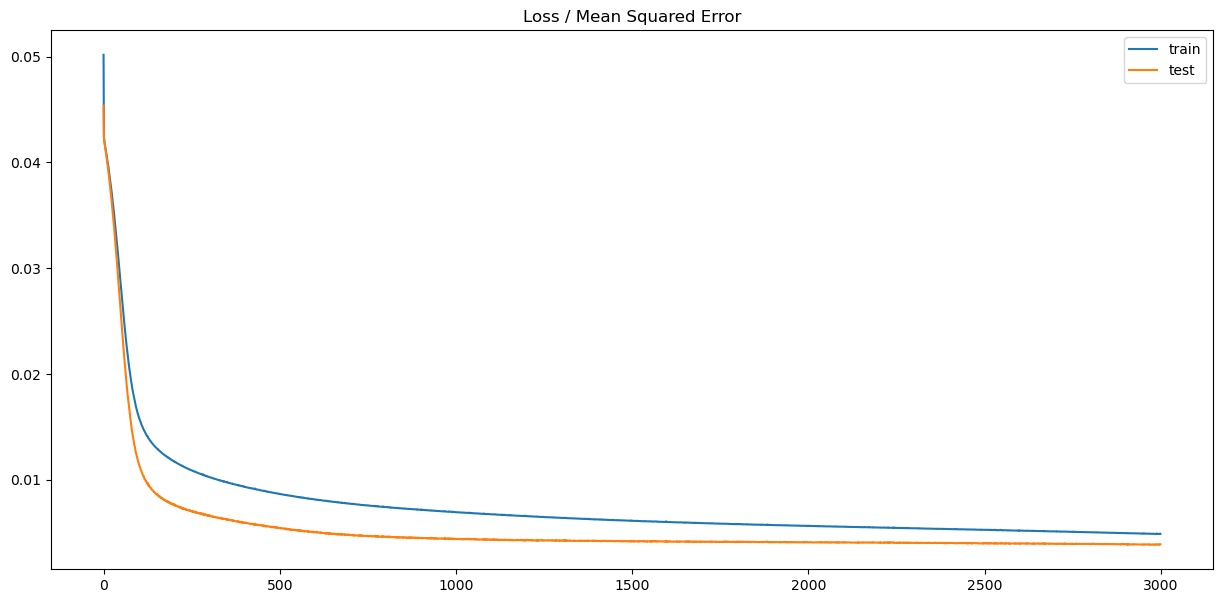

In [ ]:
# fit the keras model on the dataset

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3000, callbacks=[early_stopping], verbose=0) #
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model1.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 


0.003907123580574989

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model1.predict(df2))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     7033.
Date:                Wed, 26 Feb 2025   Prob (F-statistic):               0.00
Time:                        14:35:30   Log-Likelihood:                -5471.8
No. Observations:                 701   AIC:                         1.095e+04
Df Residuals:                     699   BIC:                         1.096e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2180     58.090     -0.038      0.9

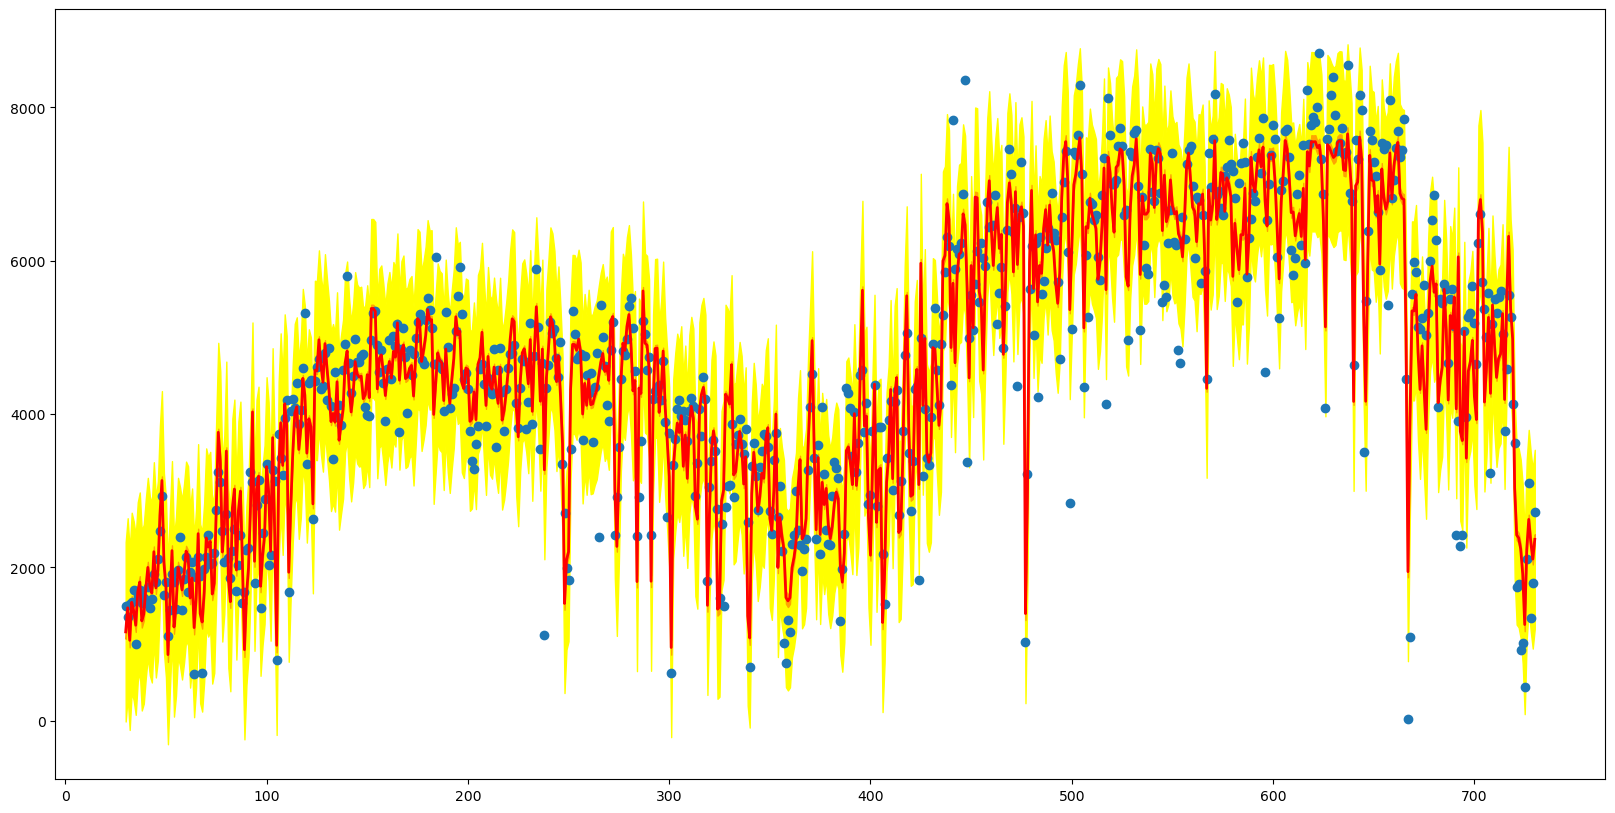

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  353650.4588835184


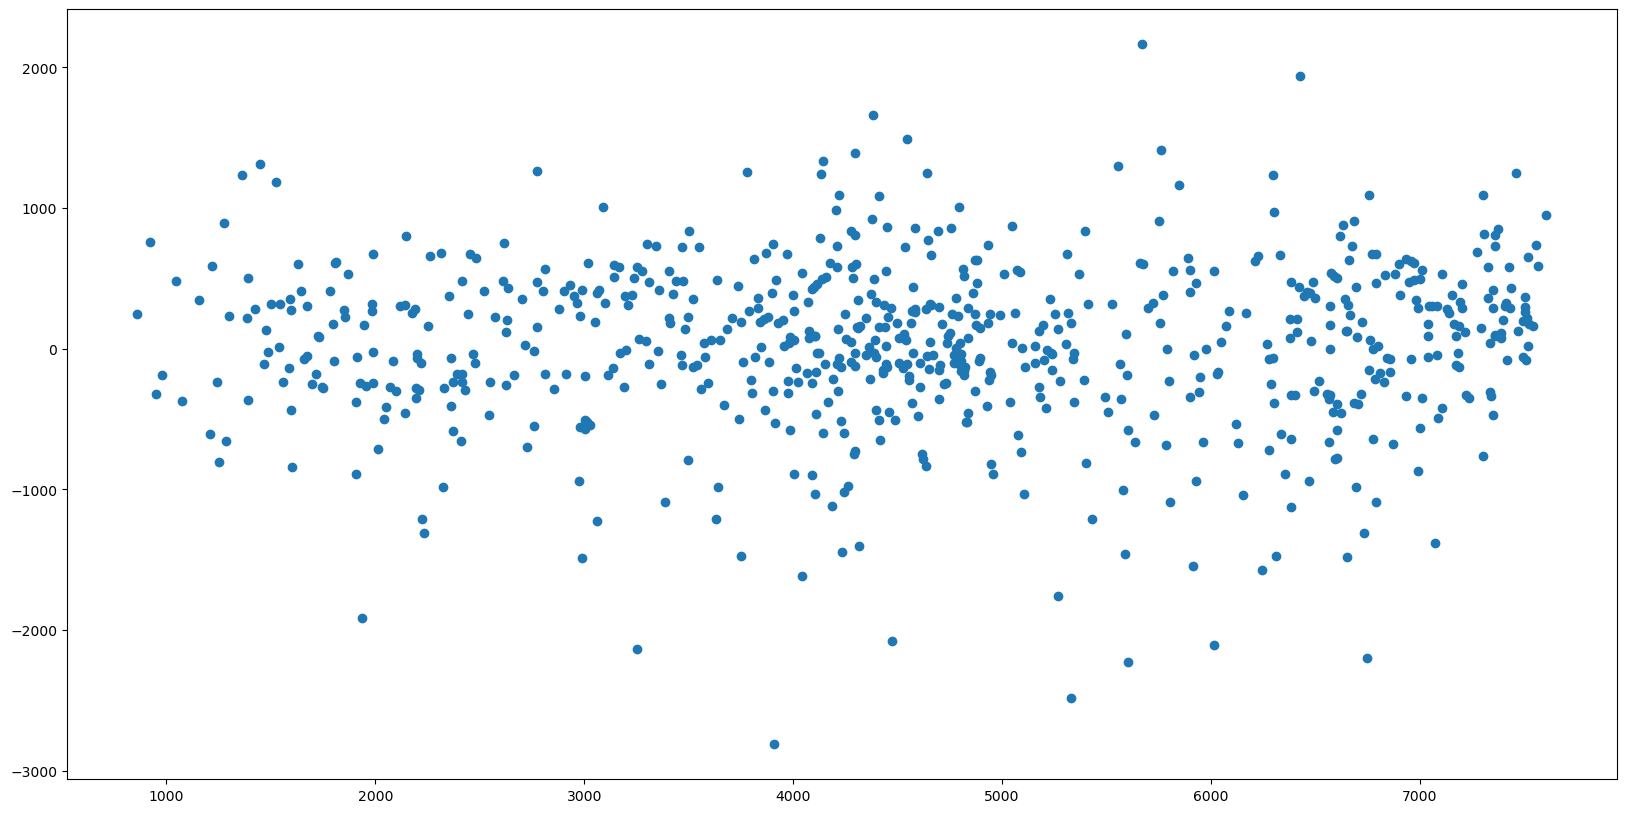

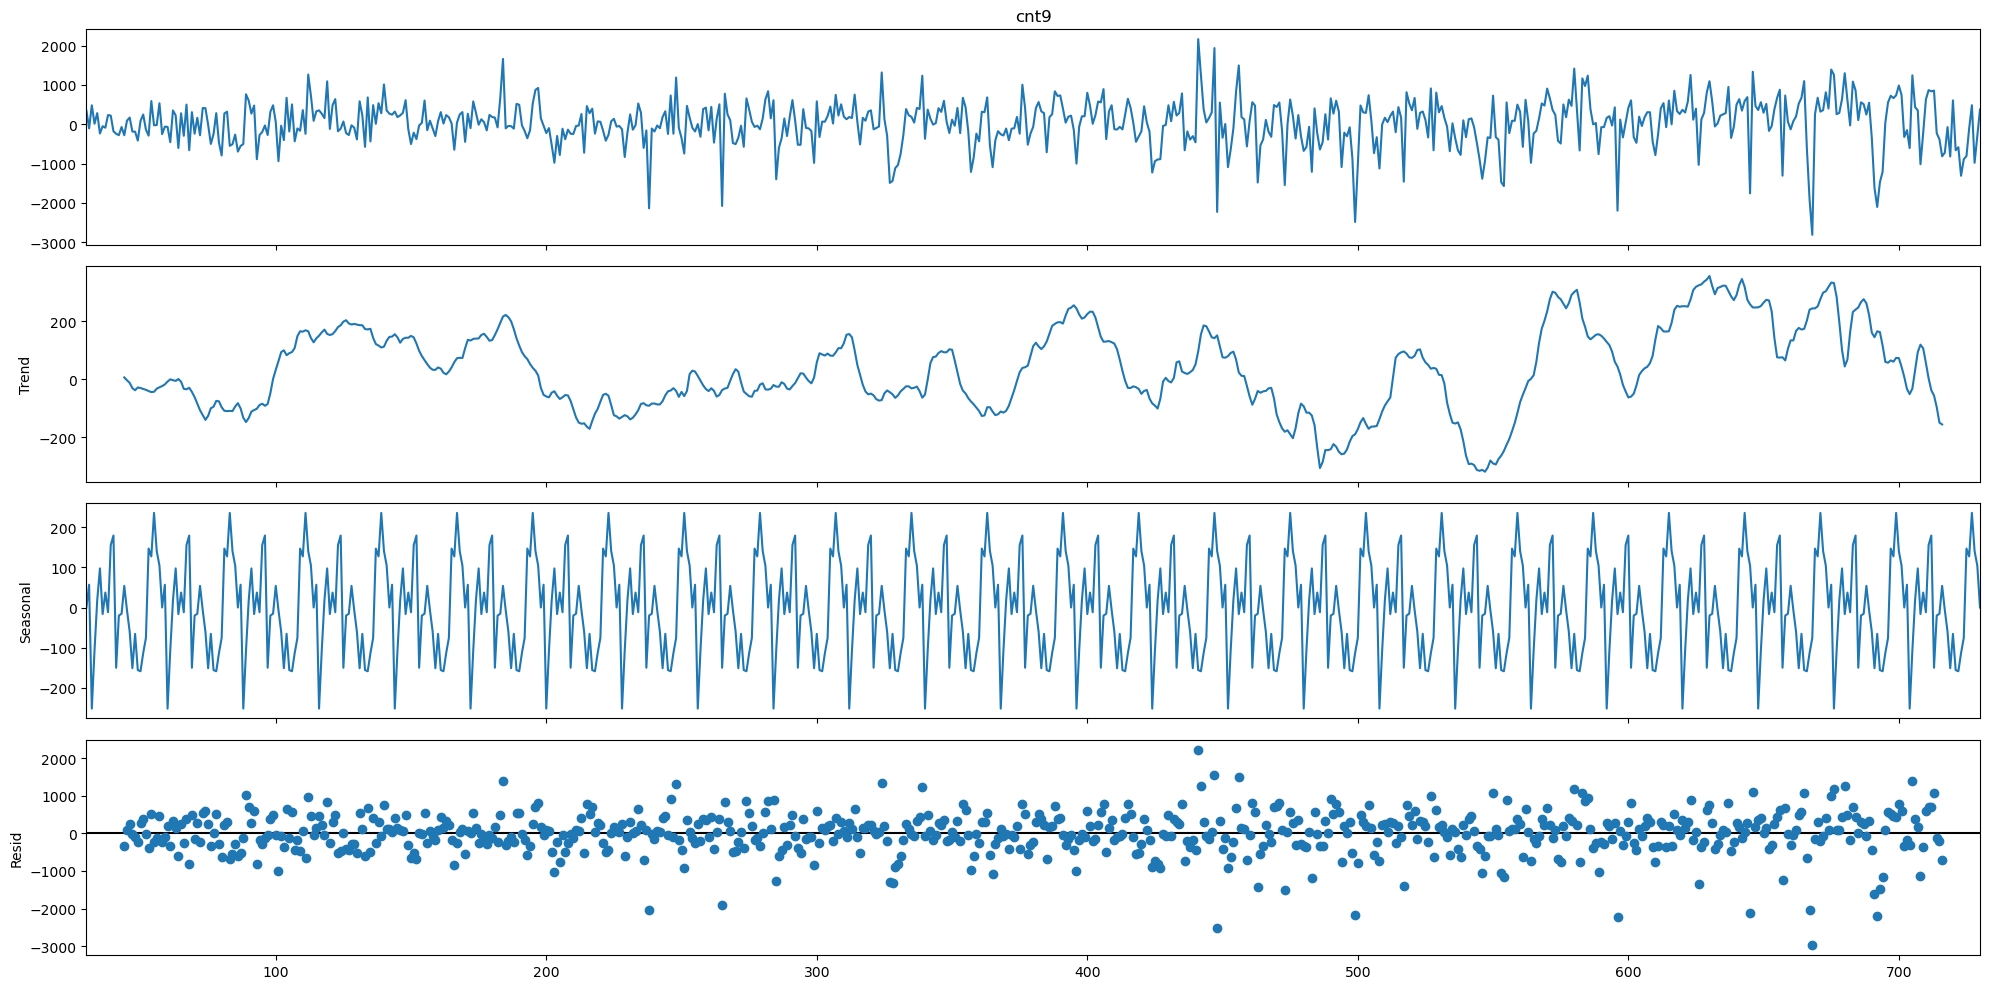

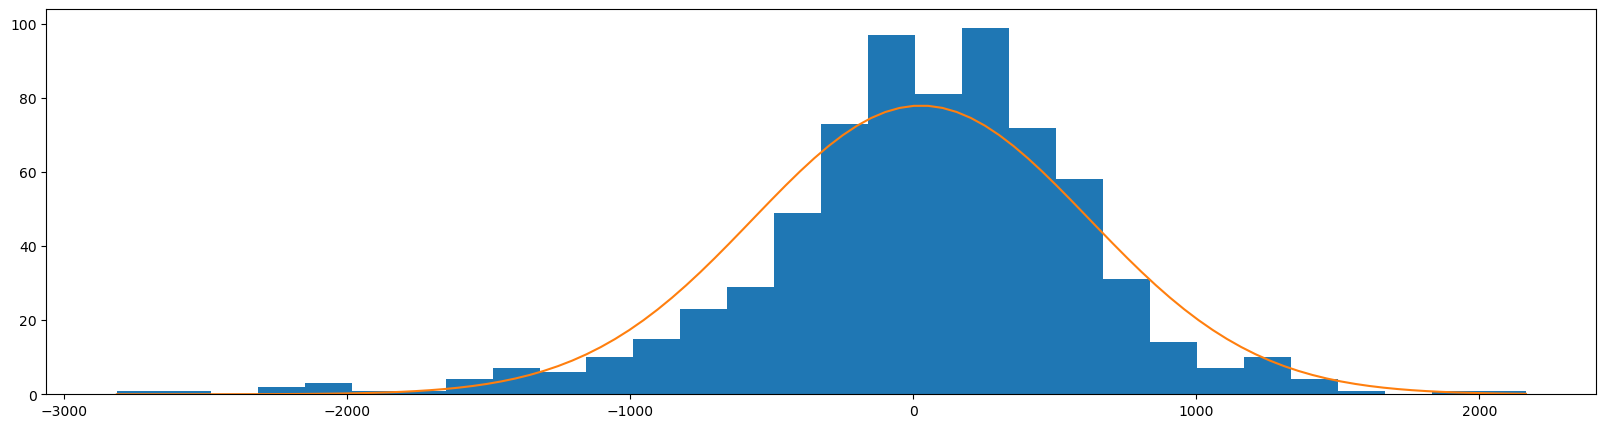

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  1.243082941108003e-12
Критерий Пирсона (проверка на нормальность, p>0.05): 3.412168409930894e-21
Критерий Харке-Бера (проверка на нормальность, p>0.05): 1.0353884394308843e-49
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  2.608554750295986e-26
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  1.2027408751563627e-12
Критерий Стьюдента (проверка на несмещенность, p>0.05):  0.214723892914048


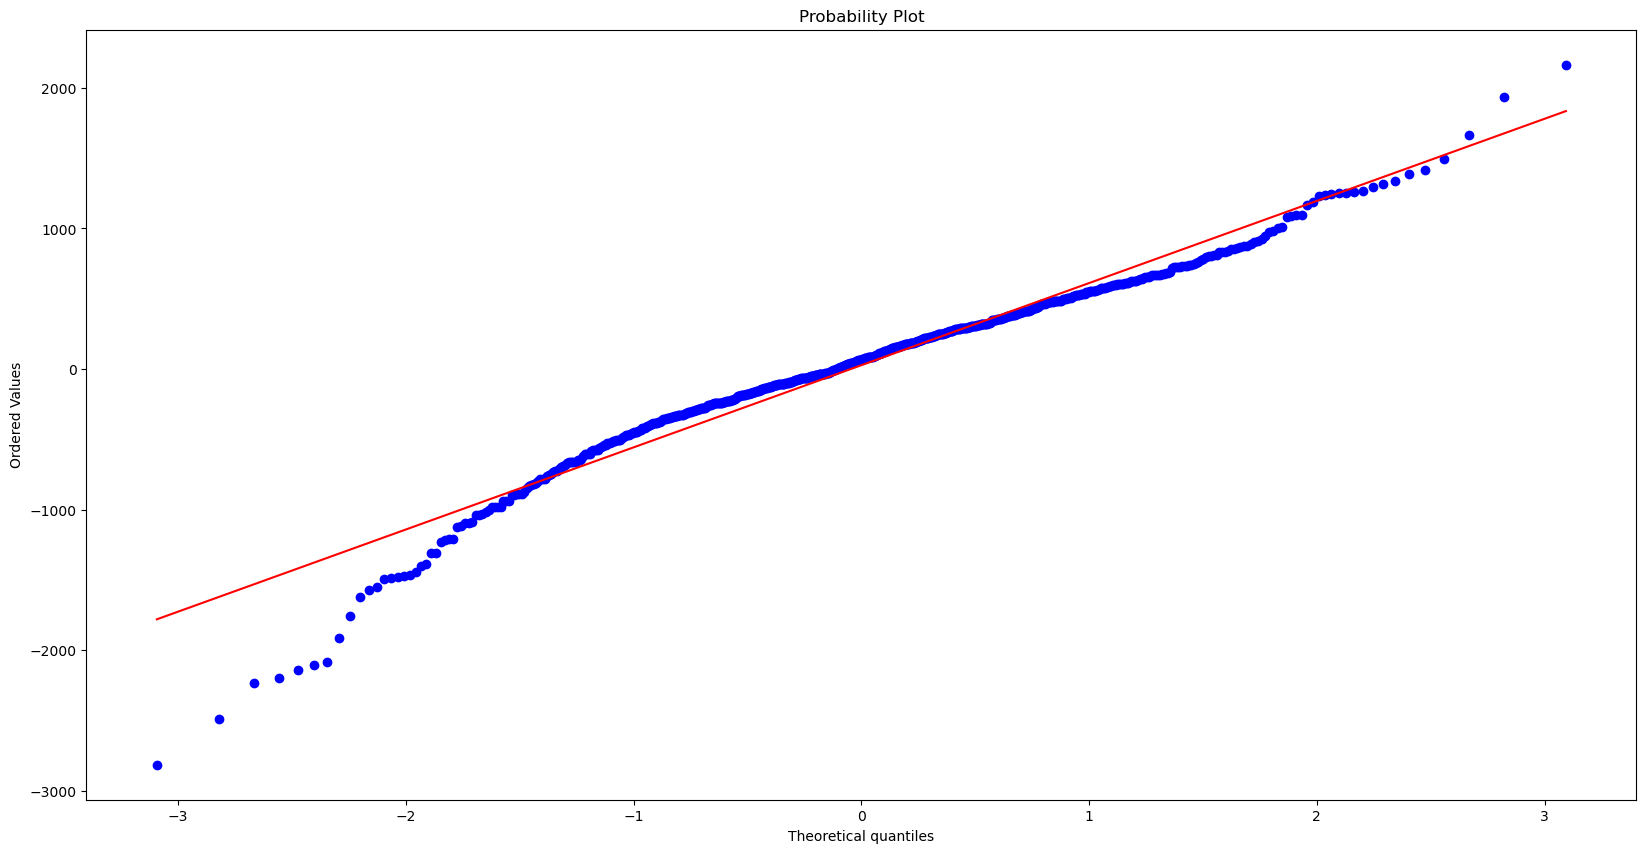

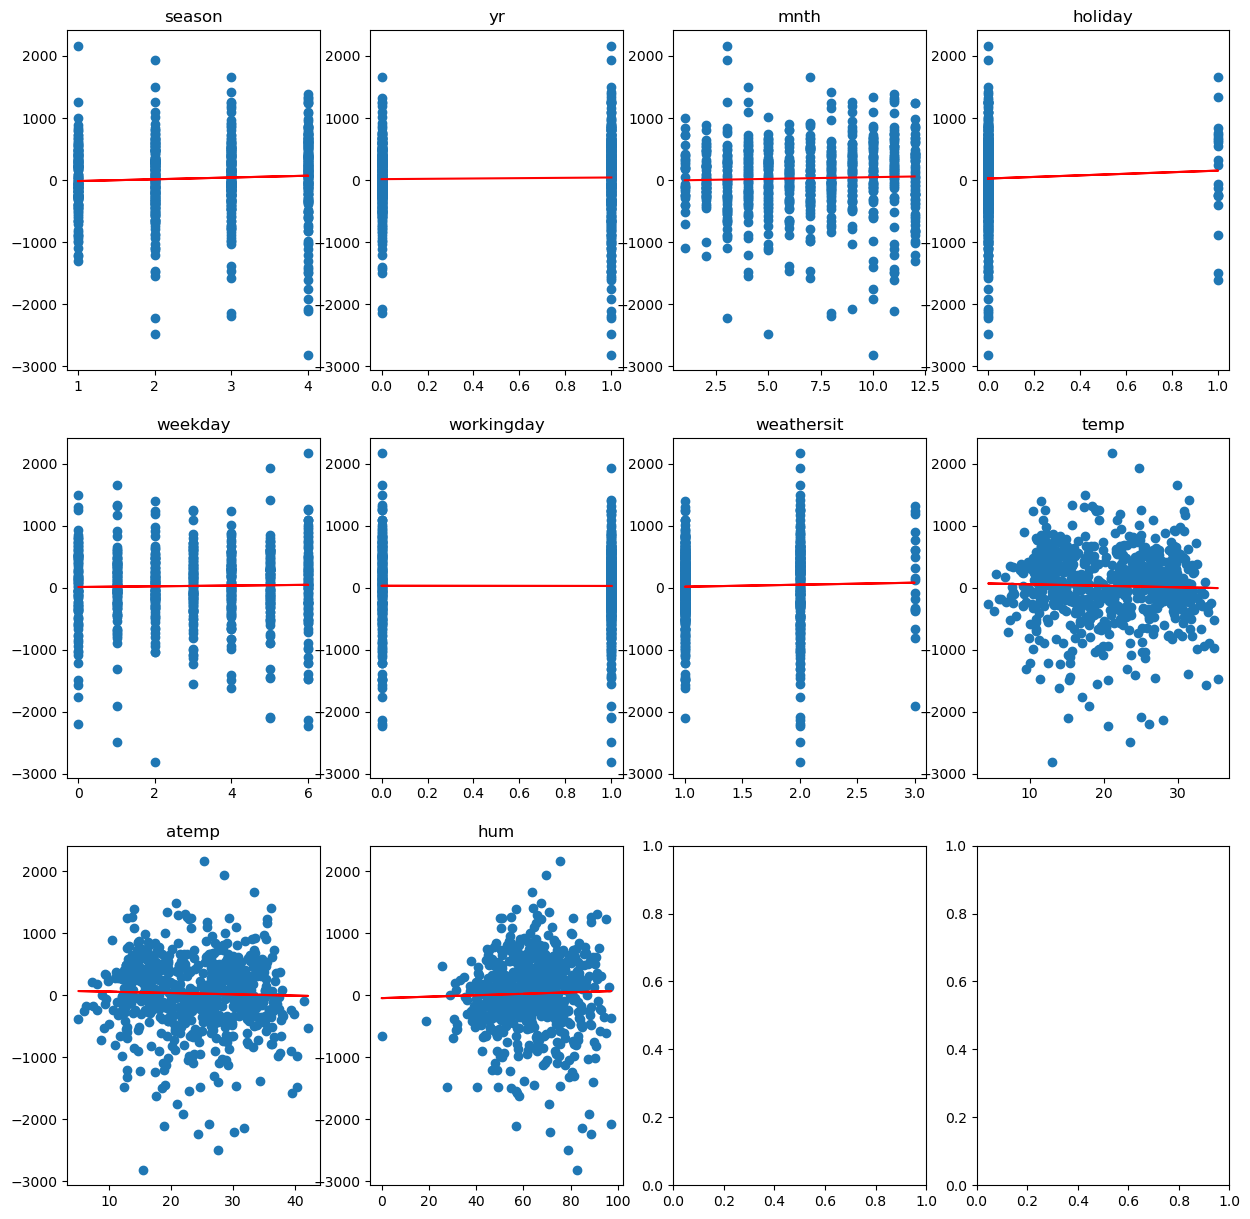

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

# Строим обобщенно-регрессиюнную (GRNN) нейронную сеть

In [ ]:
class InitCentersBGM(Initializer):
    """ Initializer for initialization of centers of RBF network
        as BayesianGaussianMixture clustering from the given data set.

    # Arguments
        X: matrix, dataset to choose the centers from (random rows
          are taken as centers)
    """

    def __init__(self, shape, X):
        self.X = X
        self.BGM = BayesianGaussianMixture(n_components=shape).fit(self.X)
        self.means_ = self.BGM.means_.T

    def __call__(self, shape, dtype=None):
        return self.means_

In [ ]:
class RBFLayer(Layer):
    def __init__(self, units, gamma, initializer=None, **kwargs):
        self.output_dim = units
        self.units = units
        self.gamma = K.cast_to_floatx(gamma)
        if not initializer:
            self.initializer = RandomUniform(0.0, 1.0)
        else:
            self.initializer = initializer
        super(RBFLayer, self).__init__(**kwargs)

    def build(self, input_shape):
#         print(input_shape)
#         print(self.units)
        self.mu = self.add_weight(name='mu',
                                  shape=(int(input_shape[1]), self.units),
                                  initializer=self.initializer,#'uniform',
                                  trainable=True)
#        print(self.mu[0])

        super(RBFLayer, self).build(input_shape)

    def call(self, inputs):
        diff = K.expand_dims(inputs) - self.mu
        l2 = K.sum(K.pow(diff, 2), axis=1)
        res = K.exp(-1 * self.gamma * l2)
        return res

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

In [ ]:
il1 = Input(shape=(len(X_train.columns),))
rbf1 = RBFLayer(50, 0.5, initializer = InitCentersBGM(50, X_train))(il1)
d11 = Dense(15, activation='sigmoid')(rbf1)
d21 = Dense(15, activation='sigmoid')(d11)
d41 = Dense(1, activation='sigmoid')(d21)
model2 = Model(il1, d41)

model2.compile(loss='mean_squared_error', optimizer=RMSprop())

model2.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 35)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rbf_layer (RBFLayer)                 │ (None, 50)                  │           1,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │             765 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 15)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,771 (10.82 KB)

 Trainable params: 2,771 (10.82 KB)

 Non-trainable params: 0 (0.00 B)

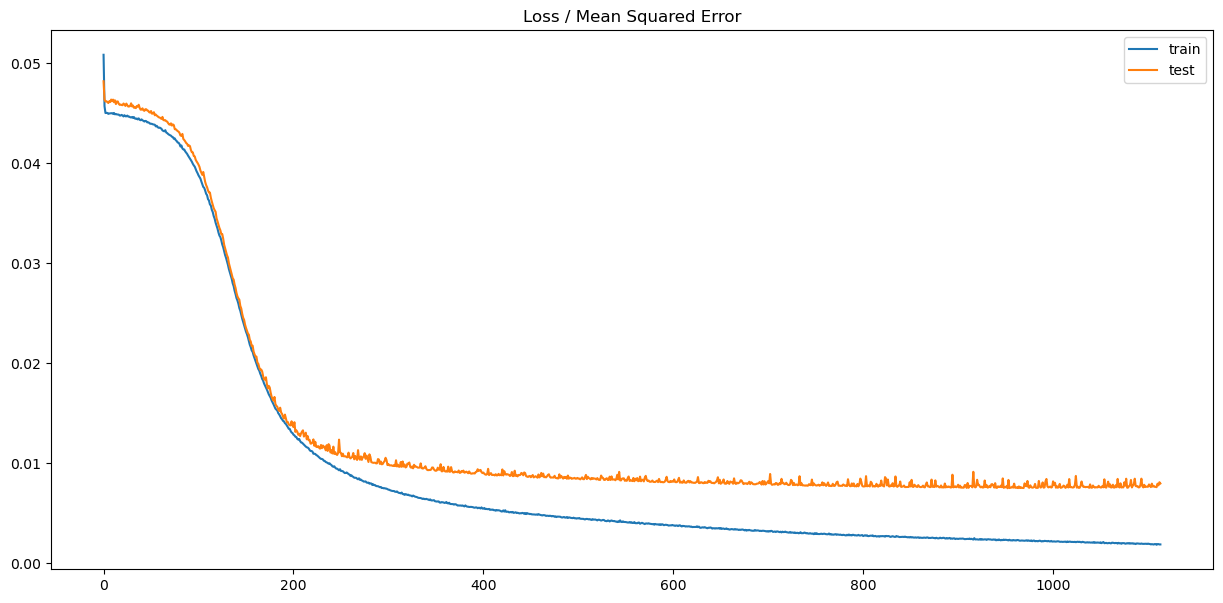

In [ ]:

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3000, callbacks=[early_stopping], batch_size=50,verbose=0) #
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model2.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 


0.00798504613339901

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model2.predict(df2))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                 1.164e+04
Date:                Sun, 25 Aug 2024   Prob (F-statistic):               0.00
Time:                        21:27:05   Log-Likelihood:                -5321.4
No. Observations:                 701   AIC:                         1.065e+04
Df Residuals:                     699   BIC:                         1.066e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     92.4409     50.233      1.840      0.0

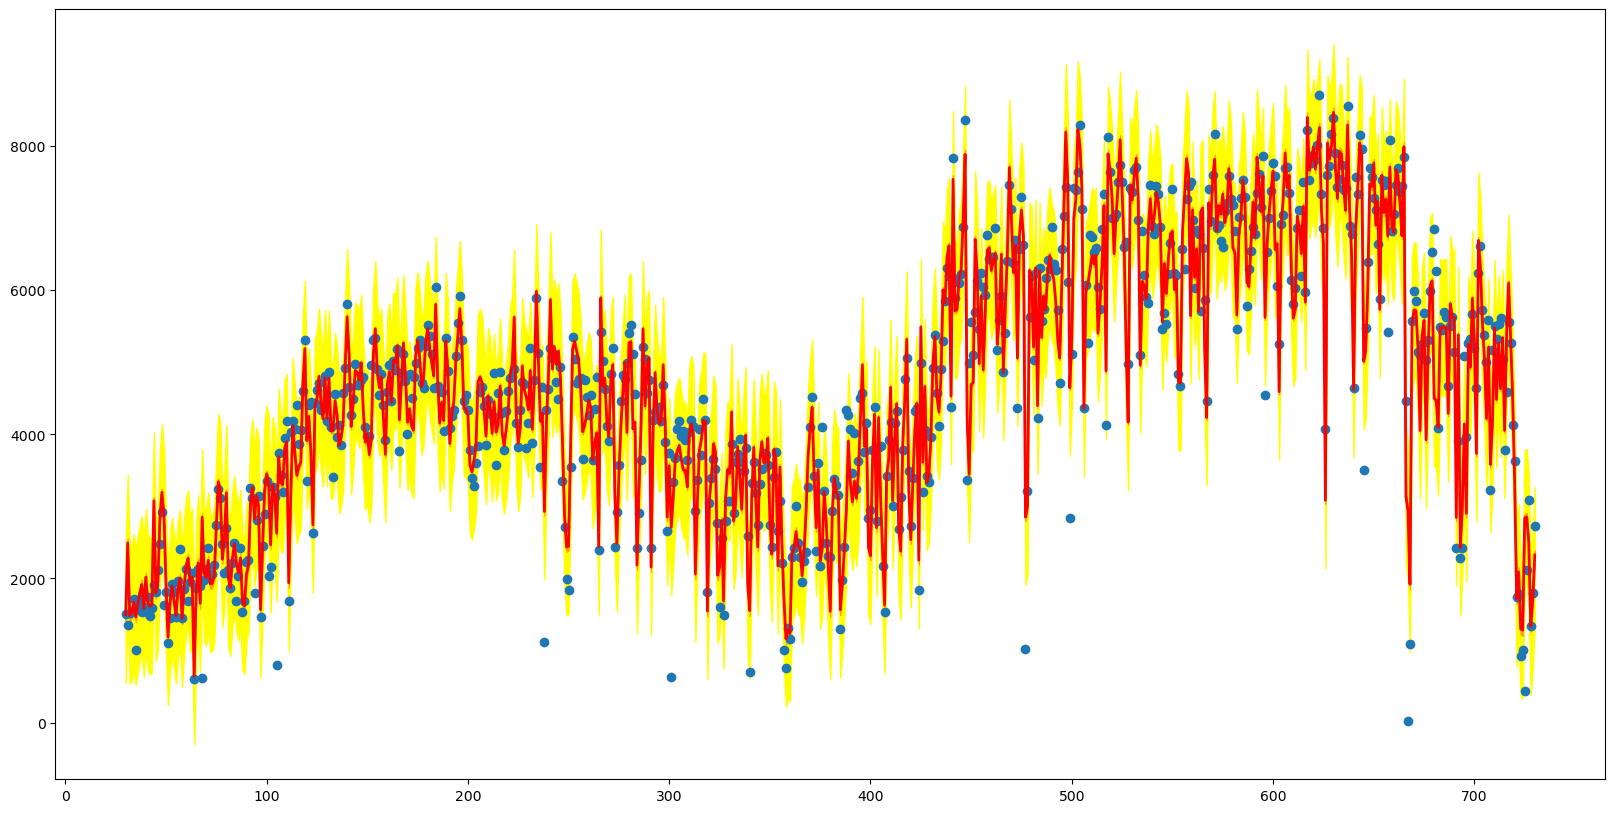

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  238110.4798670458


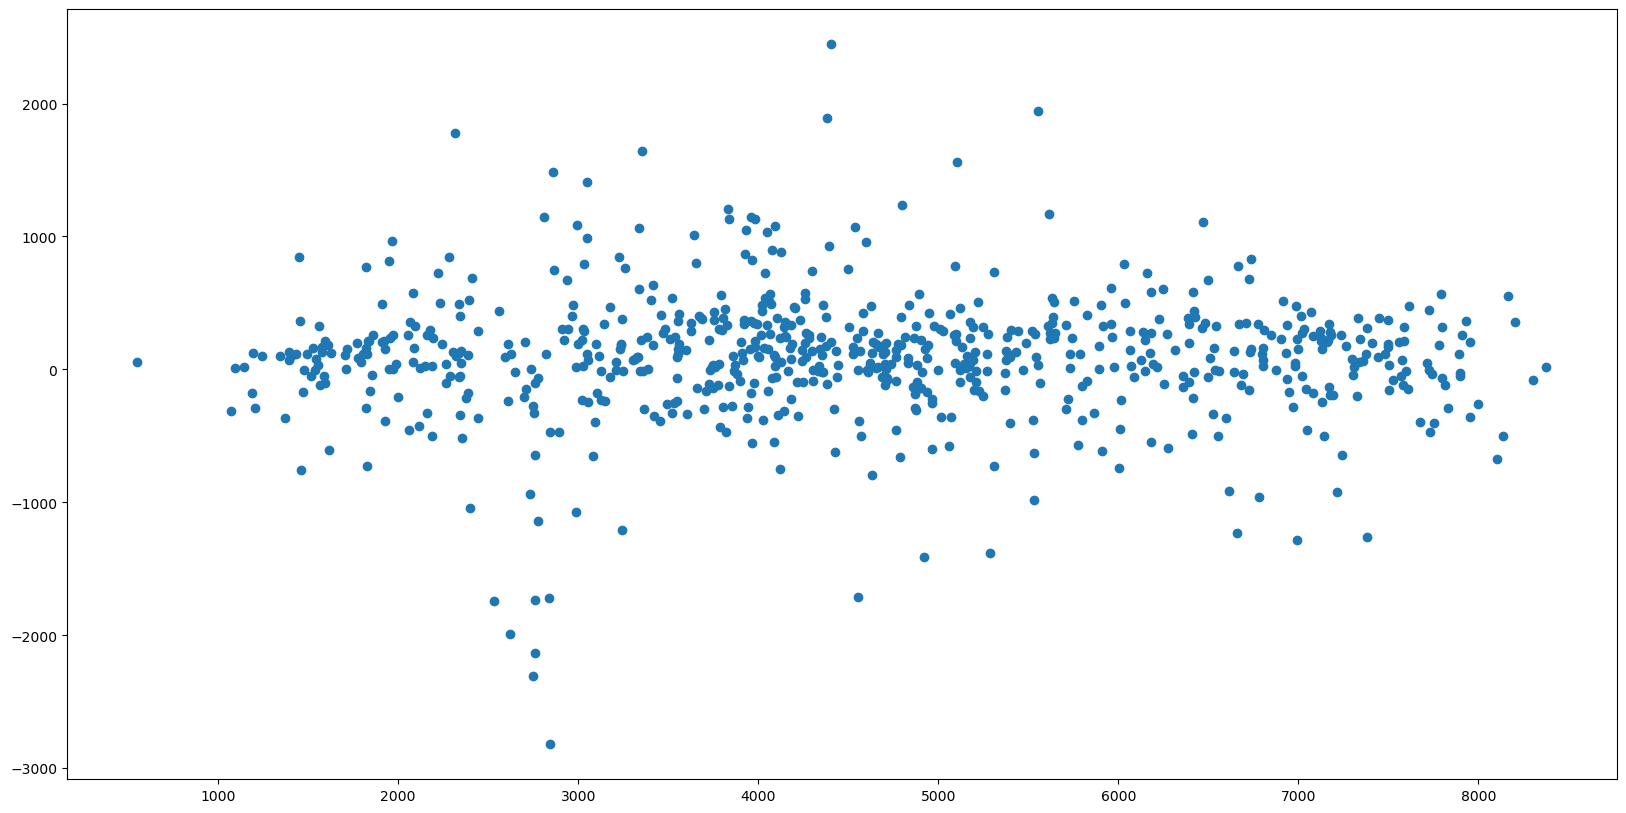

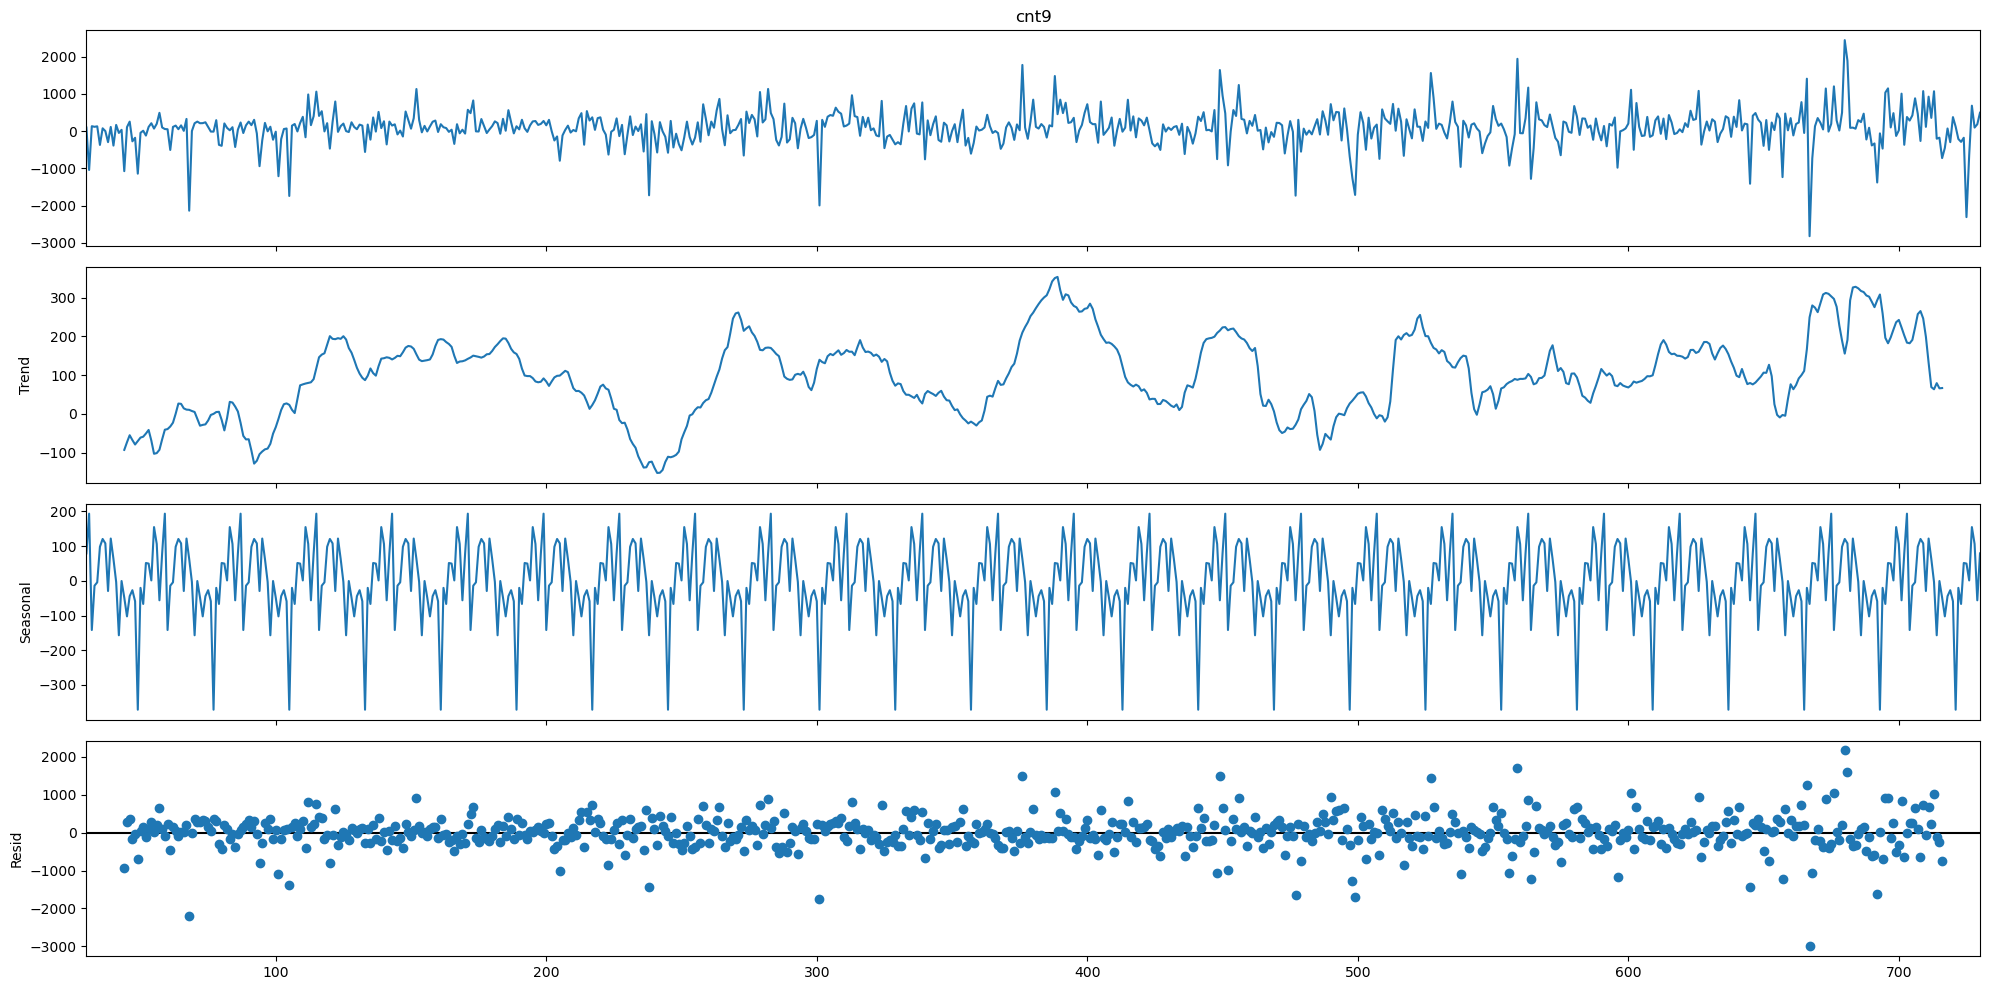

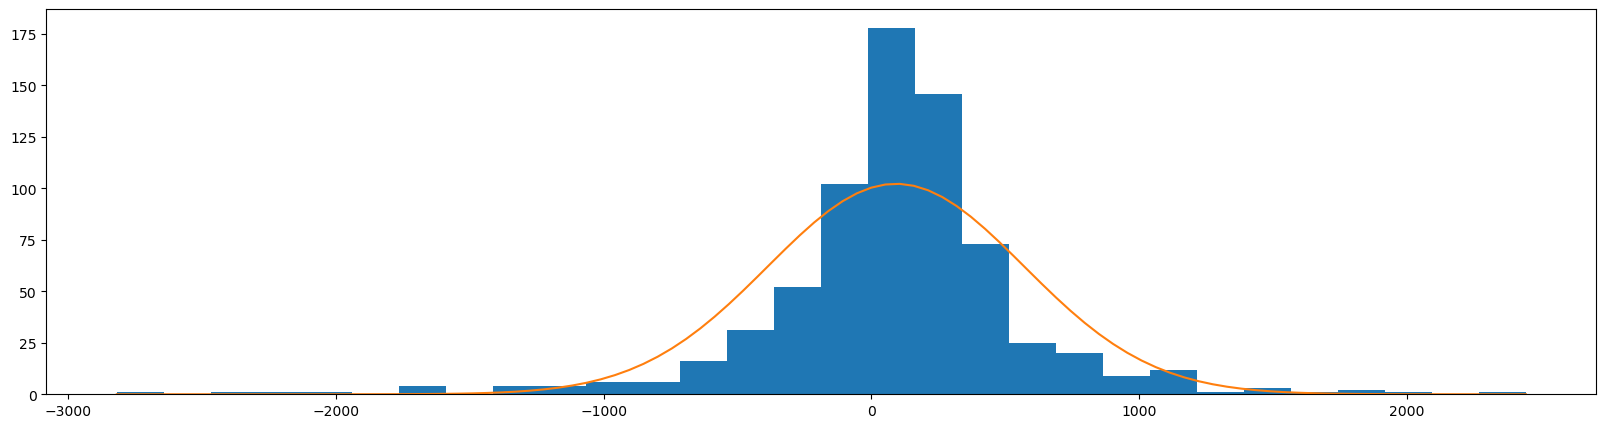

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  3.8815938316462966e-21
Критерий Пирсона (проверка на нормальность, p>0.05): 4.95826375589936e-32
Критерий Харке-Бера (проверка на нормальность, p>0.05): 2.548438813784272e-260
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  1.2111601626640438e-29
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  7.615926376566733e-08
Критерий Стьюдента (проверка на несмещенность, p>0.05):  5.129451543398404e-07


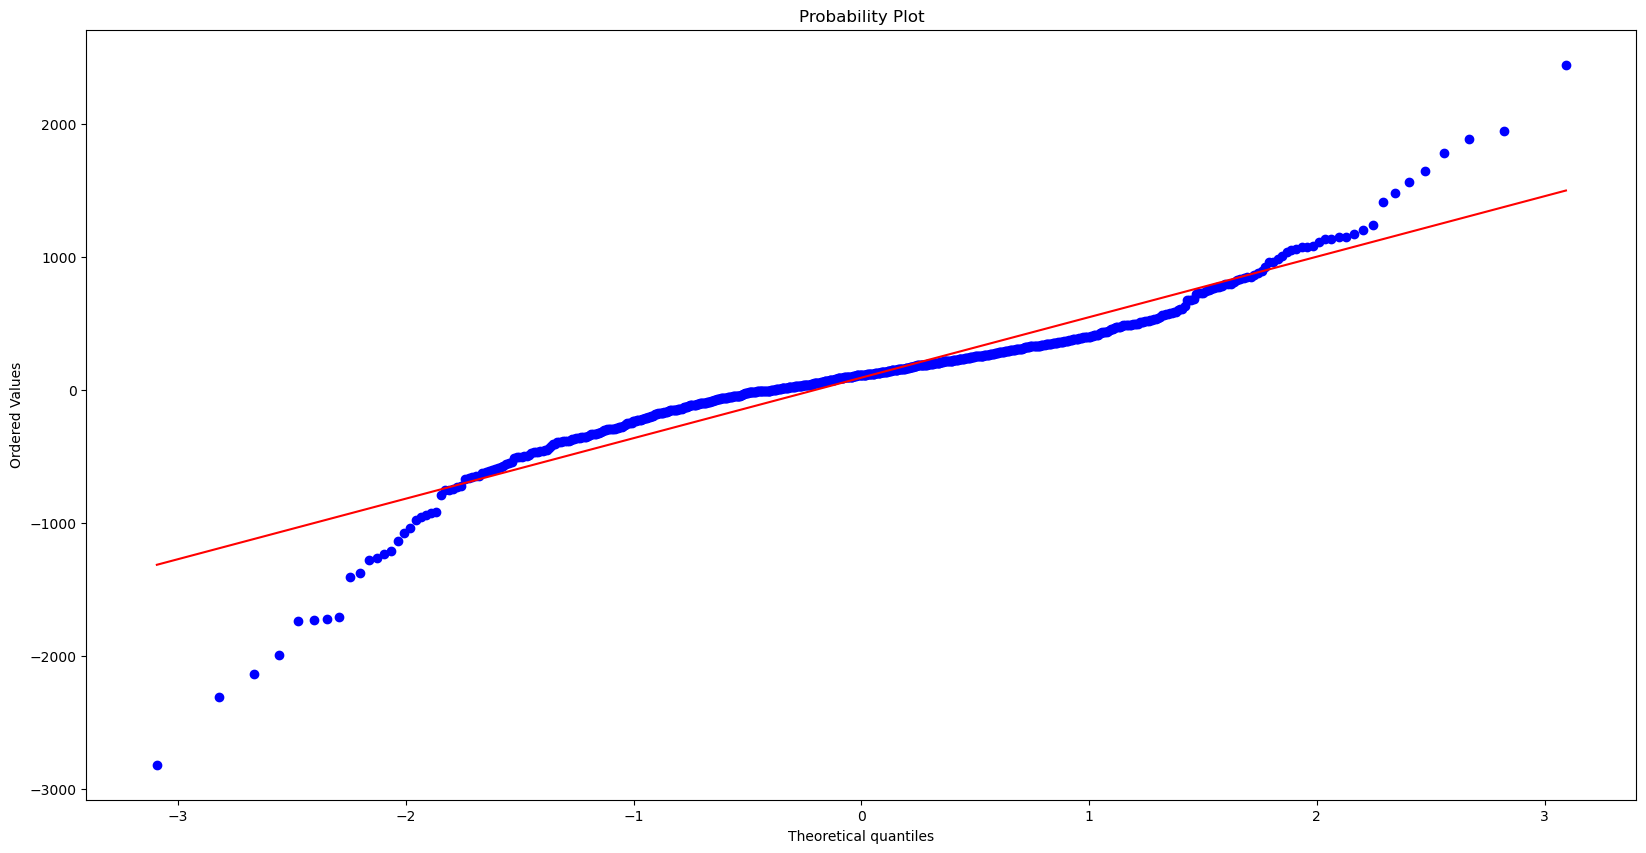

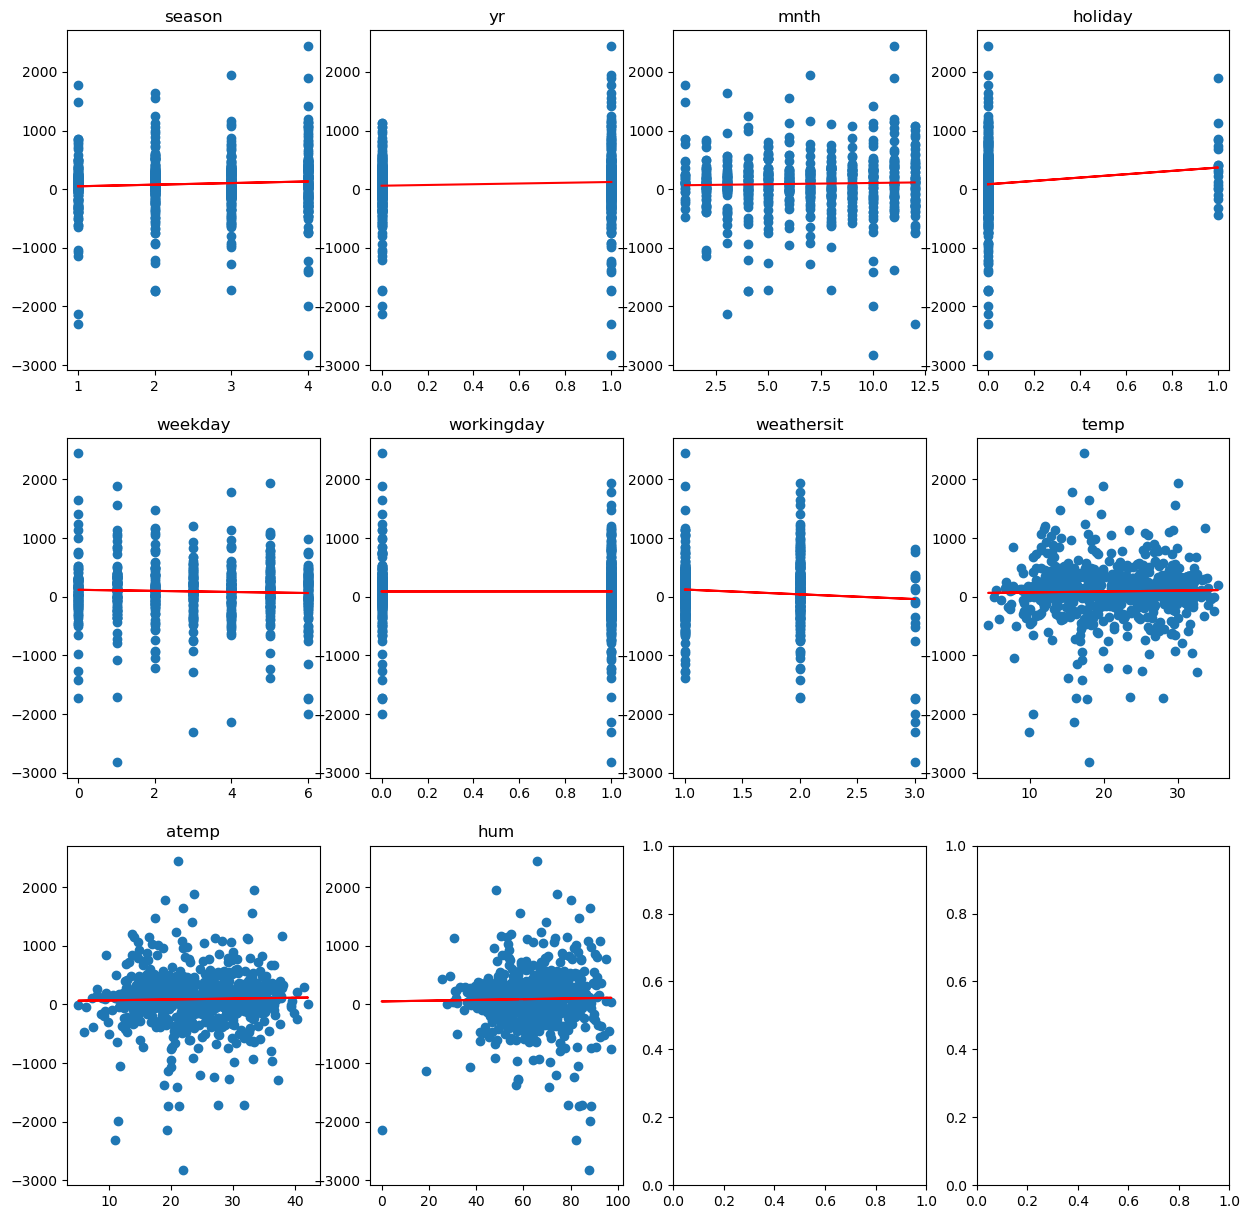

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

 # Строим комбинацию GRNN и MLP

In [ ]:
il2 = Input(shape=(len(X_train.columns),))
rbf2 = RBFLayer(50, 0.5, initializer = InitCentersBGM(50, X_train))(il2)
d12 = Dense(15, activation='sigmoid')(rbf2)
d22 = Dense(15, activation='sigmoid')(il2)
cn2 = Concatenate()([d12,d22])
#rsh = Reshape((30,1))(cn)
d32 = Dense(15, activation='sigmoid')(cn2)
d42 = Dense(1, activation='sigmoid')(d32)
model3 = Model(il2, d42)
model3.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 35)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rbf_layer_1 (RBFLayer)        │ (None, 50)                │           1,750 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 15)                │             765 │ rbf_layer_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 15)                │             540 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 30)                │               0 │ dense_6[0][0],             │
│                               │                           │                 │ dense_7[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 15)                │             465 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 1)                 │              16 │ dense_8[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,536 (13.81 KB)

 Trainable params: 3,536 (13.81 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.compile(loss='mean_squared_error', optimizer=RMSprop())


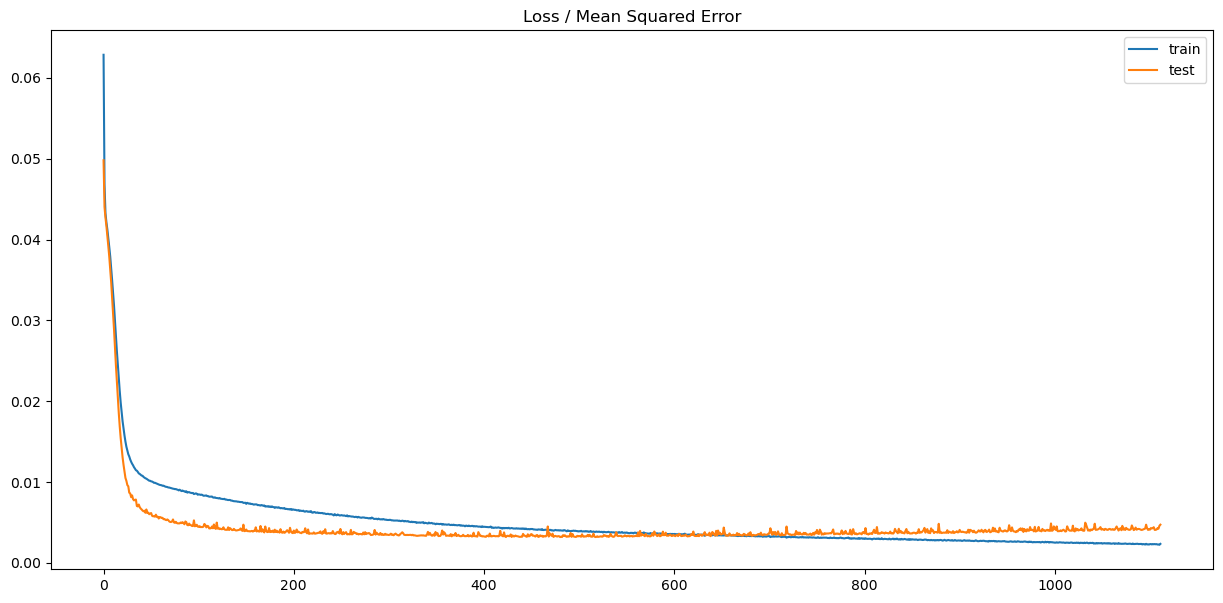

In [ ]:

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model3.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3000, callbacks=[early_stopping], verbose=0) #
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model3.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0047 


0.004715886898338795

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model3.predict(df2))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                 1.194e+04
Date:                Sun, 25 Aug 2024   Prob (F-statistic):               0.00
Time:                        21:29:36   Log-Likelihood:                -5266.1
No. Observations:                 701   AIC:                         1.054e+04
Df Residuals:                     699   BIC:                         1.055e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    130.5754     46.533      2.806      0.0

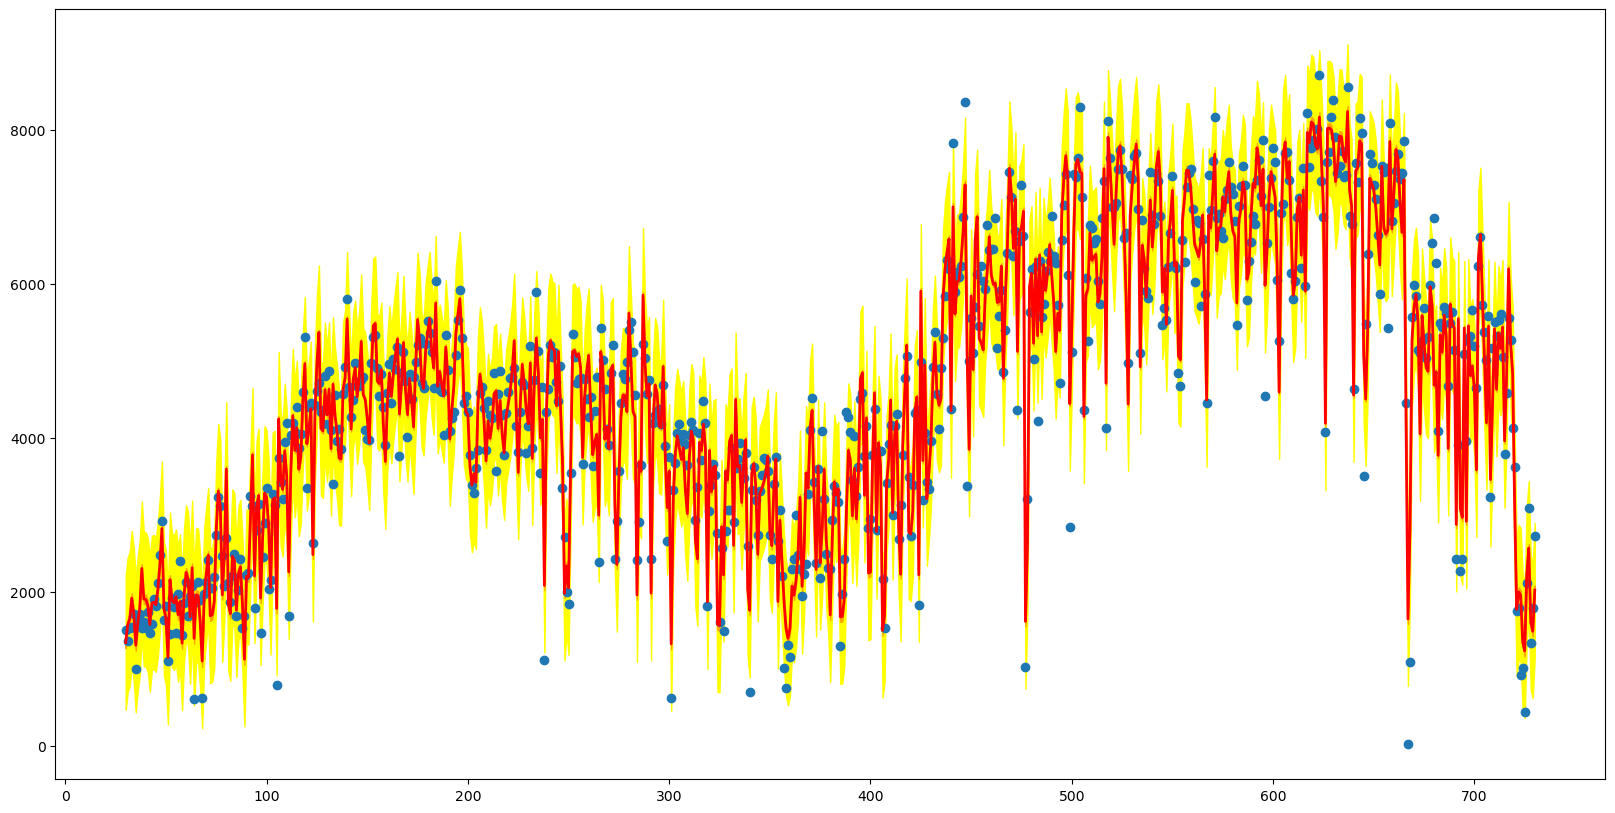

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  216985.68469604998


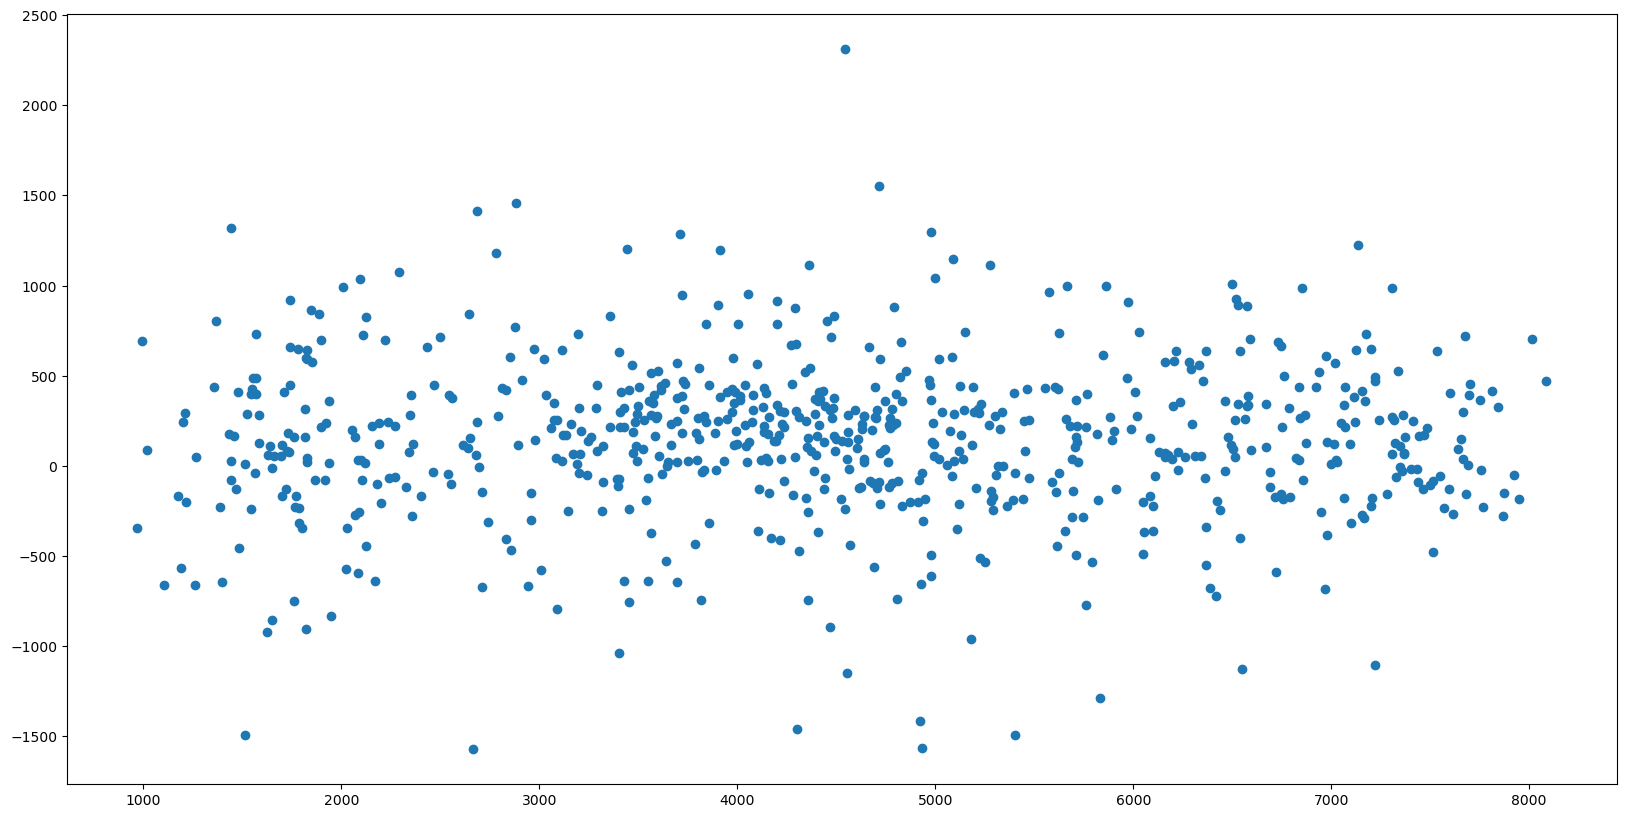

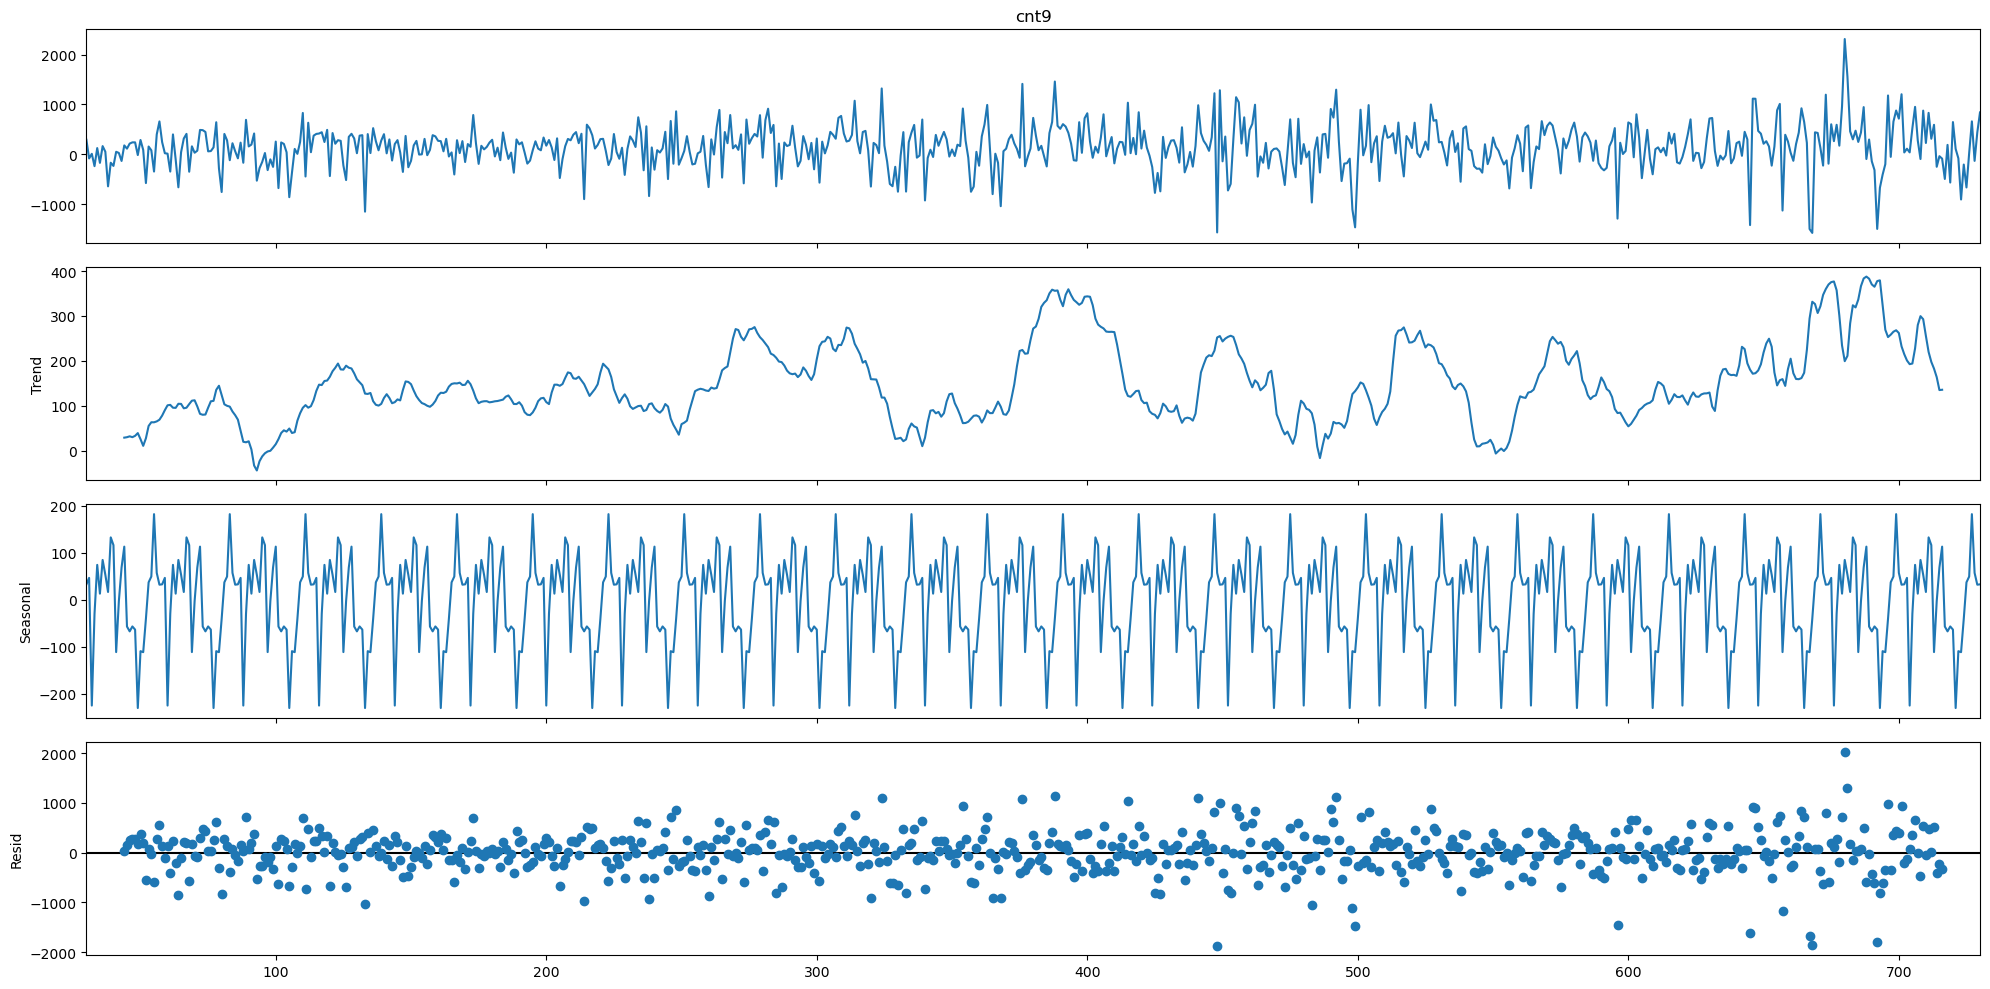

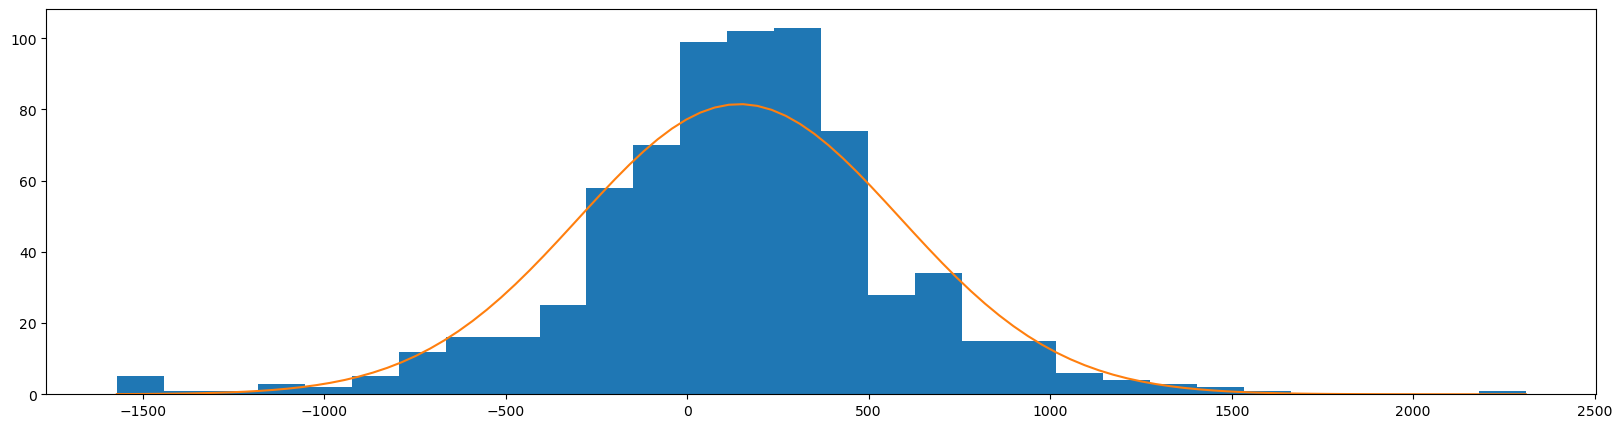

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  3.644345585500989e-11
Критерий Пирсона (проверка на нормальность, p>0.05): 2.447185956905716e-11
Критерий Харке-Бера (проверка на нормальность, p>0.05): 5.9567762165421764e-36
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  4.9034183458704143e-29
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  5.3425334418871826e-09
Критерий Стьюдента (проверка на несмещенность, p>0.05):  4.6190897742169085e-17


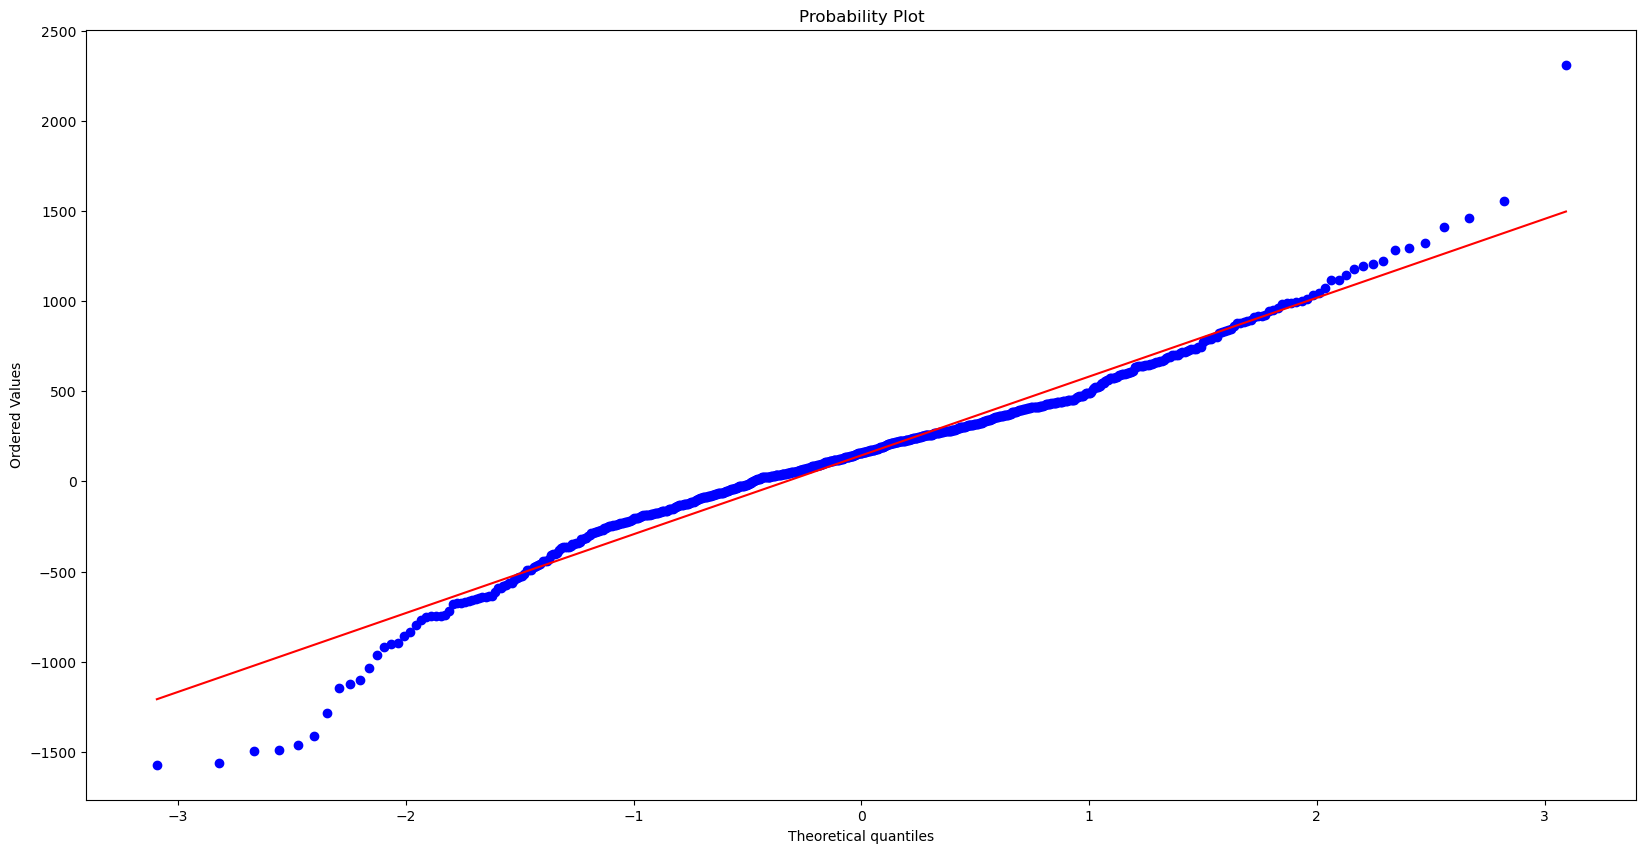

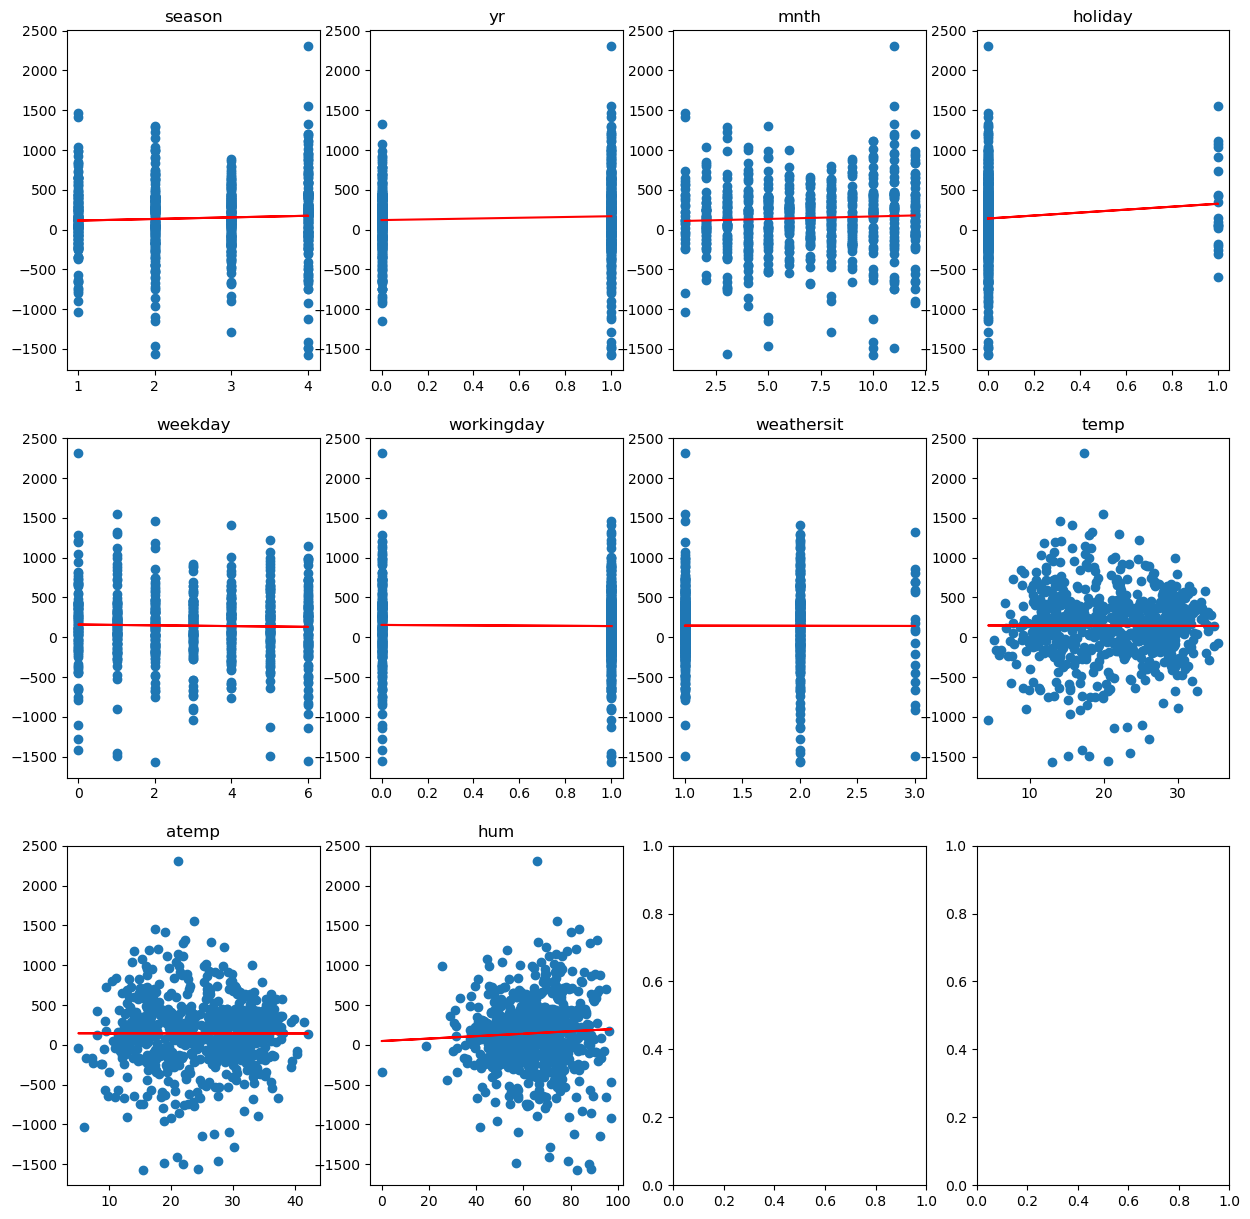

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

# Строим LSTM модель (анализируем исключительно авторегрессионную компоненту)

In [ ]:
SYMBOLS = 100

model4 = Sequential([
    Input(shape=(SHAG,)),
    Reshape((-1, SHAG)), # Приводим в двумерный формат, применимый для LSTM
    LSTM(SYMBOLS, return_sequences=True),
    LSTM(SYMBOLS, return_sequences=True),
    Flatten(), # Возвращаемся в одномерный формат
    Dense(units=15, activation='relu'),
    Dense(units=15, activation='sigmoid'),
    Dense(units=1, activation='sigmoid')
])

model4.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam())

                #metrics=[tf.metrics.MeanSquaredError()]
model4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape (Reshape)                    │ (None, 1, 30)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 1, 100)              │          52,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 1, 100)              │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 15)                  │           1,515 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 15)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,571 (525.67 KB)

 Trainable params: 134,571 (525.67 KB)

 Non-trainable params: 0 (0.00 B)

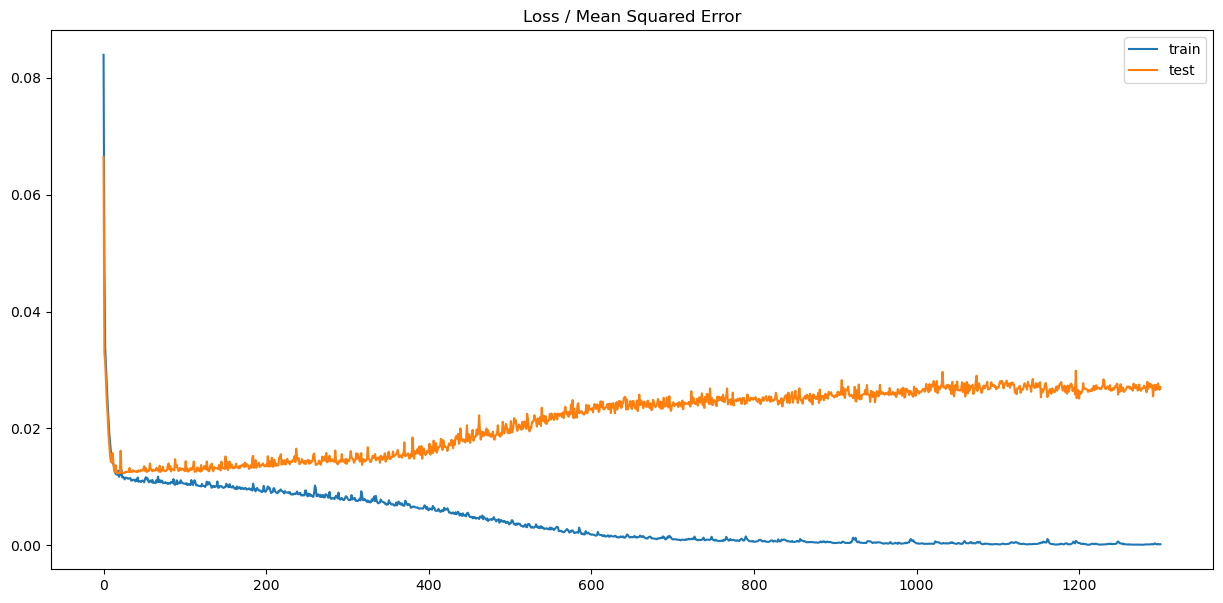

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model4.fit(XX_train, y_train,
                         validation_data=(XX_test, y_test), epochs=3000, callbacks=[early_stopping], verbose = 0)#
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model4.evaluate(XX_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0256 


0.02705274149775505

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model4.predict(XX))

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step 


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     5357.
Date:                Sun, 25 Aug 2024   Prob (F-statistic):               0.00
Time:                        21:33:07   Log-Likelihood:                -5530.0
No. Observations:                 701   AIC:                         1.106e+04
Df Residuals:                     699   BIC:                         1.107e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    215.1040     65.271      3.296      0.0

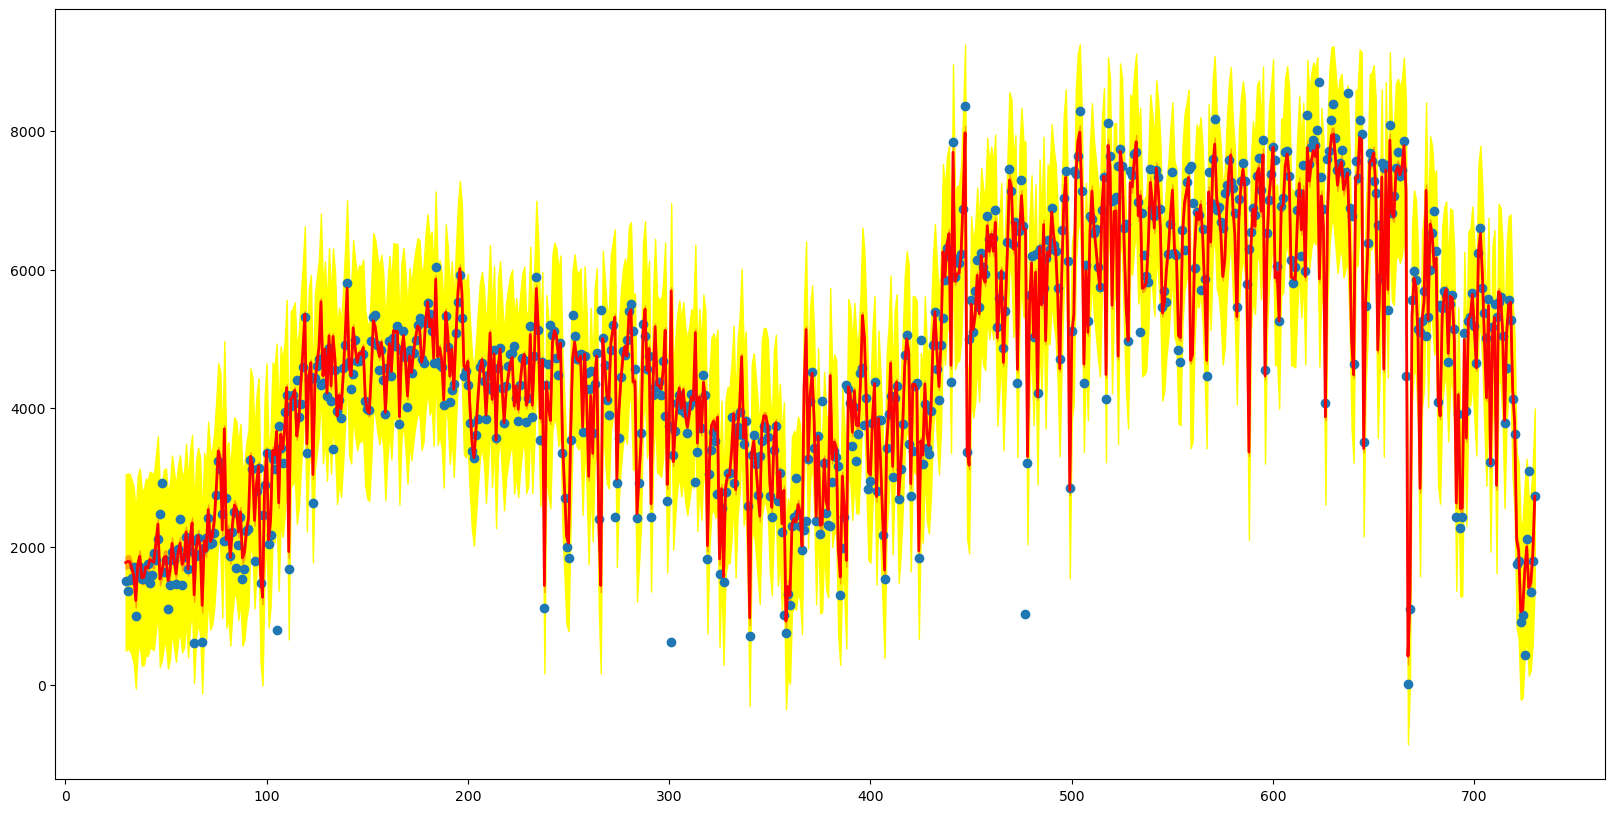

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  423808.2192361195


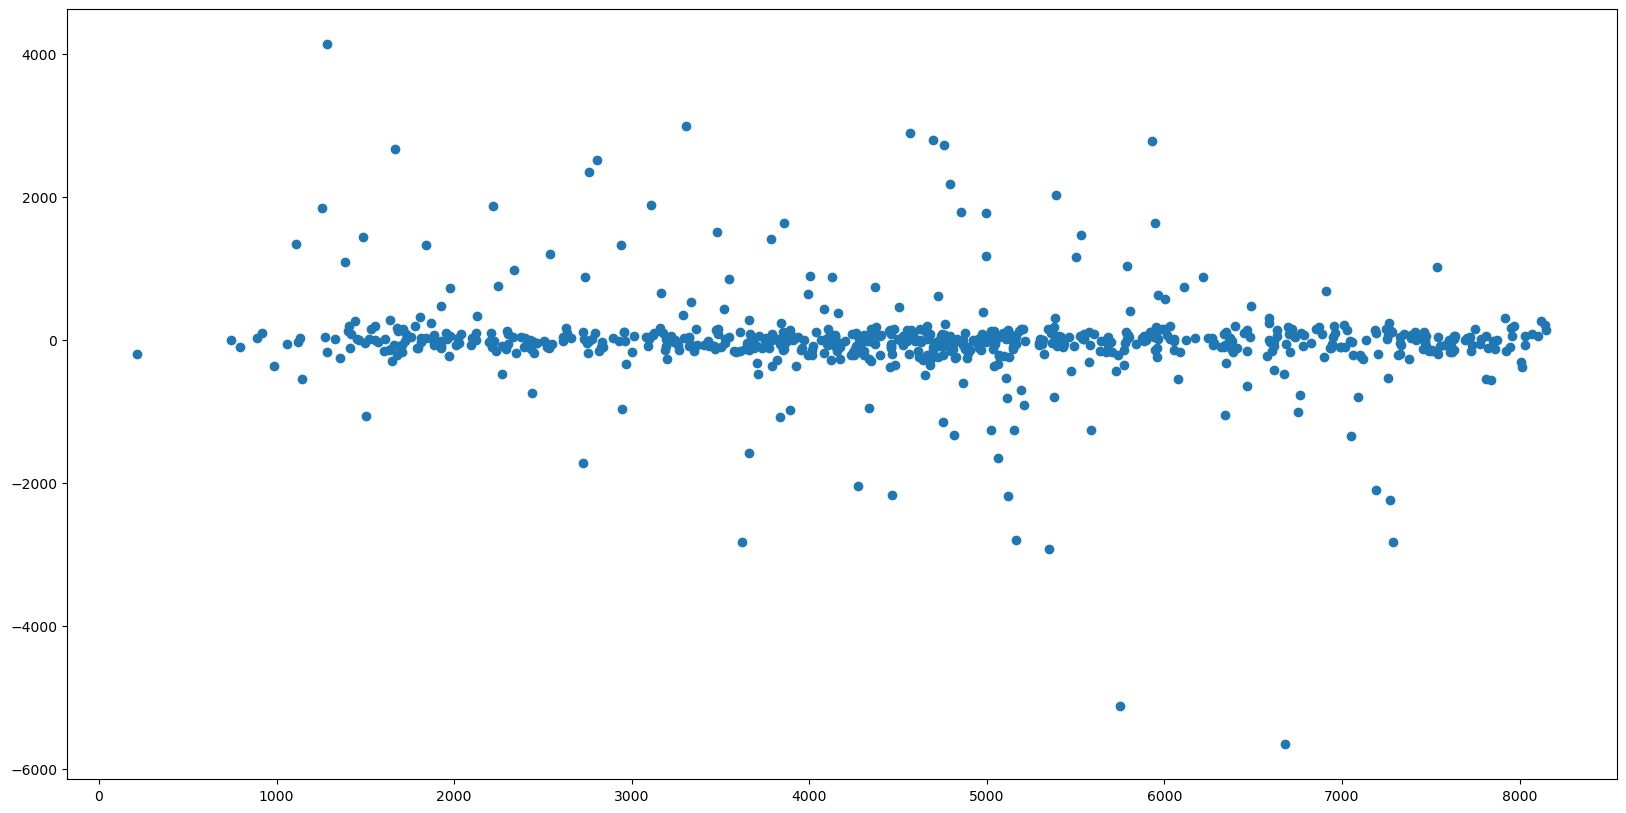

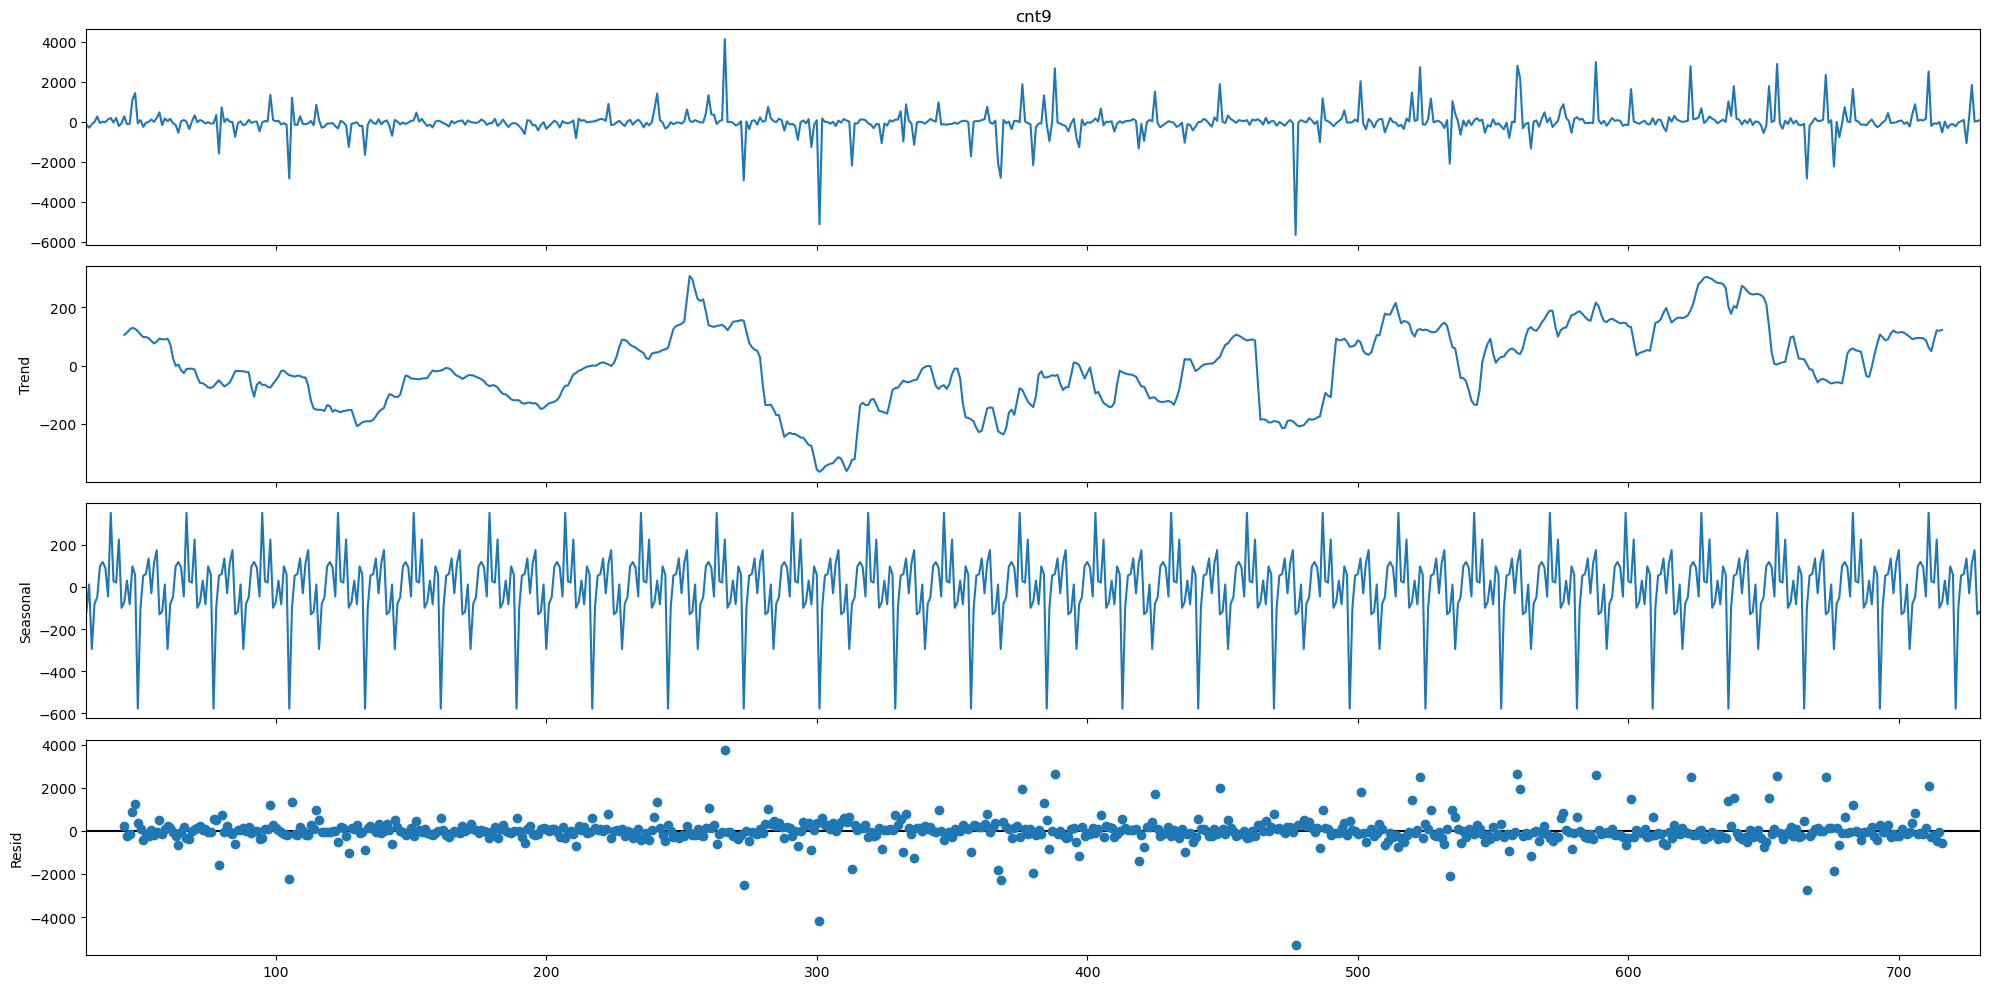

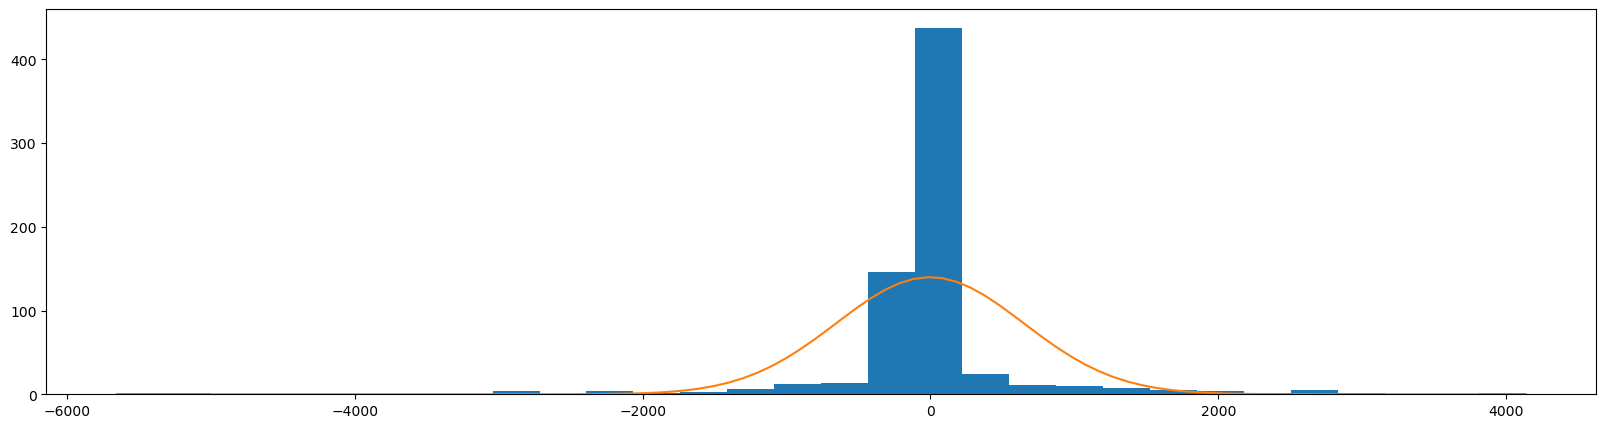

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  1.3496006061851165e-36
Критерий Пирсона (проверка на нормальность, p>0.05): 8.806025682876026e-57
Критерий Харке-Бера (проверка на нормальность, p>0.05): 0.0
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  0.0
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  0.00018437459700184014
Критерий Стьюдента (проверка на несмещенность, p>0.05):  0.8910938370775312


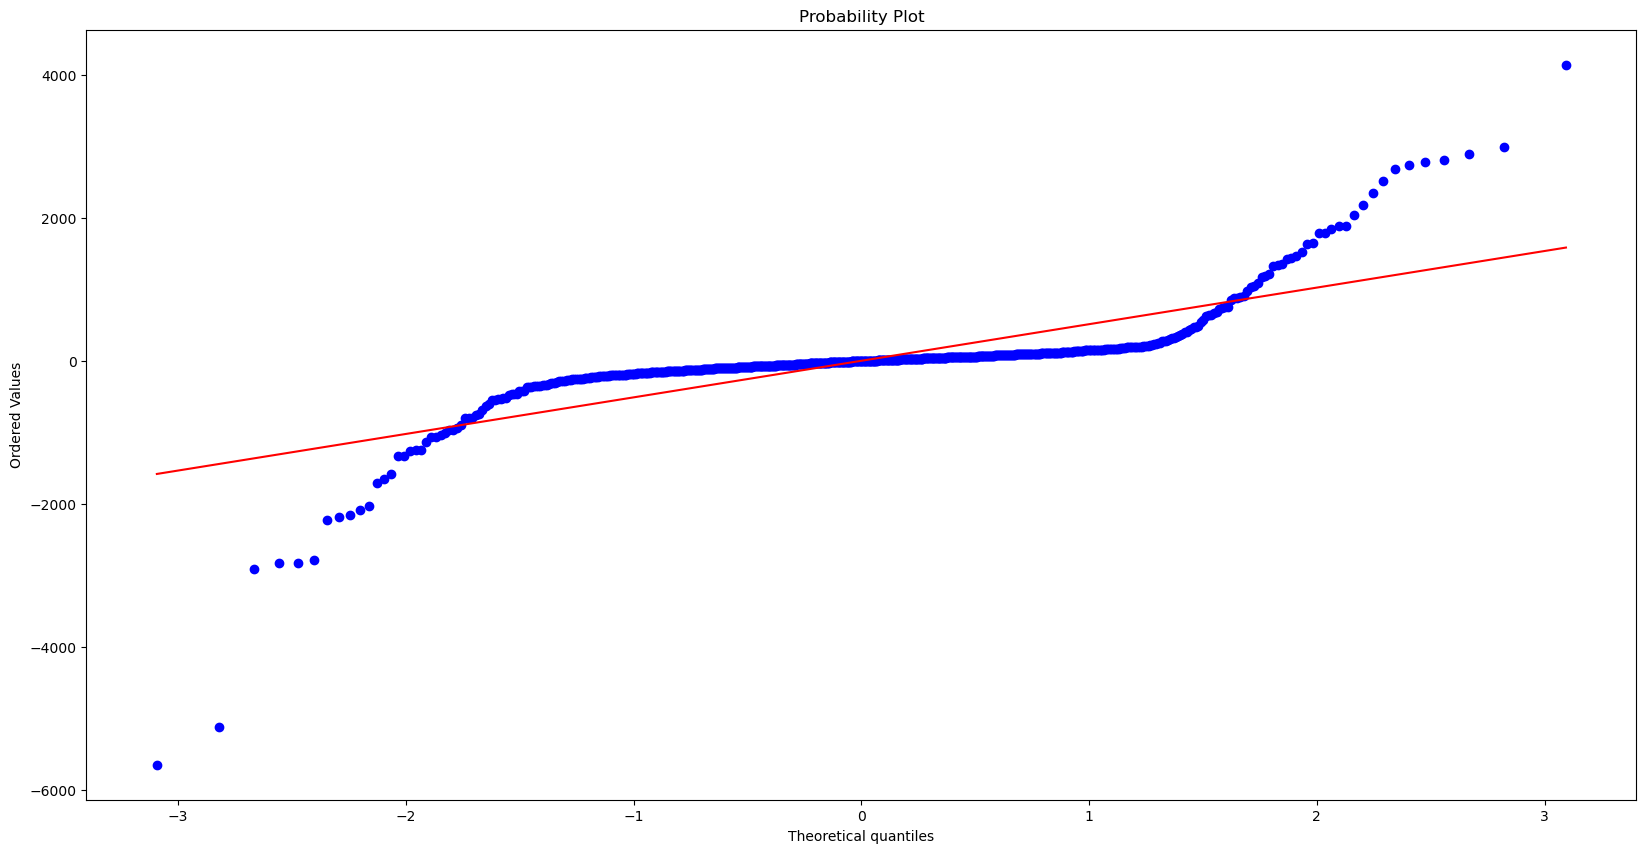

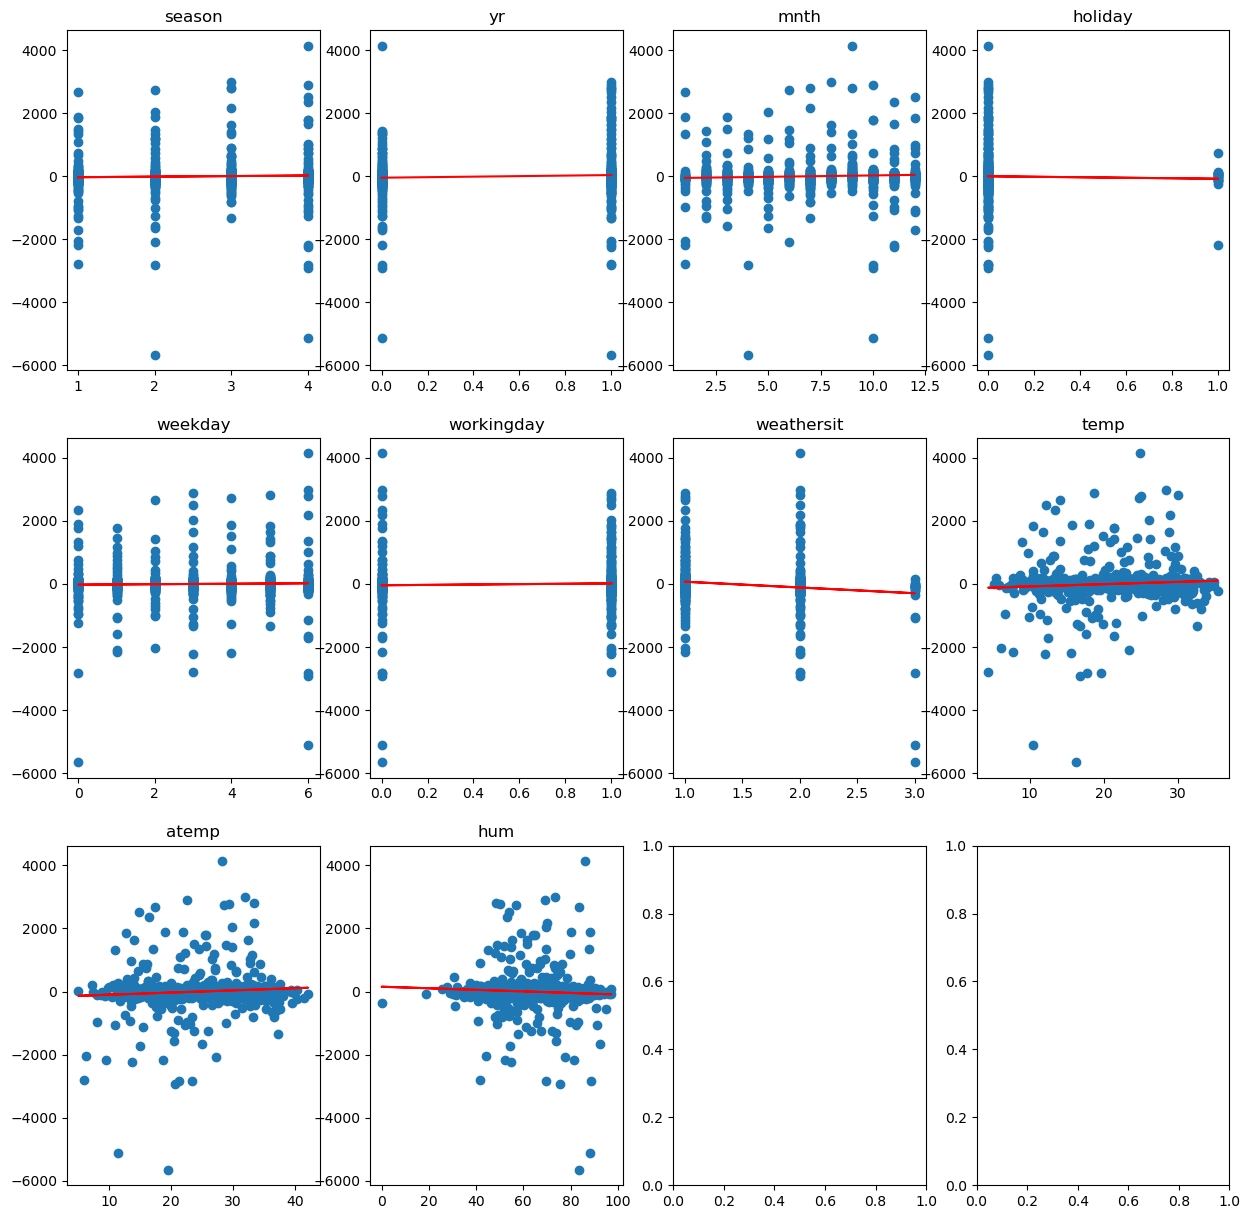

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

# Создаем сверточную сеть

## Авторегрессионная модель

In [ ]:
#MaxPool2D(pool_size=(3,3), strides=(2,2)),
model5 = Sequential([
    Input(shape=(XX_train.shape[1], XX_train.shape[2])),
    Conv1D(filters=100, kernel_size=(6), strides=(1), activation='relu'),
    BatchNormalization(),
    Conv1D(filters=100, kernel_size=(5), strides=(2), activation='relu'),
    BatchNormalization(),
    Conv1D(filters=15, kernel_size=(3), strides=(1), activation='relu'),
    BatchNormalization(),
    Flatten(), # Возвращаемся в одномерный формат
    Dense(units=15, activation='relu'),
    Dense(units=15, activation='relu'),
    Dense(units=1, activation='sigmoid')

])
opt = SGD(learning_rate=0.001)#, momentum=0.9)
model5.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=opt)#tf.optimizers.Adam())

                #metrics=[tf.metrics.MeanSquaredError()]
model5.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 25, 100)             │             700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 25, 100)             │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 11, 100)             │          50,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 100)             │             400 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 9, 15)               │           4,515 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 9, 15)               │              60 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 135)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 15)                  │           2,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 15)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,471 (228.40 KB)

 Trainable params: 58,041 (226.72 KB)

 Non-trainable params: 430 (1.68 KB)

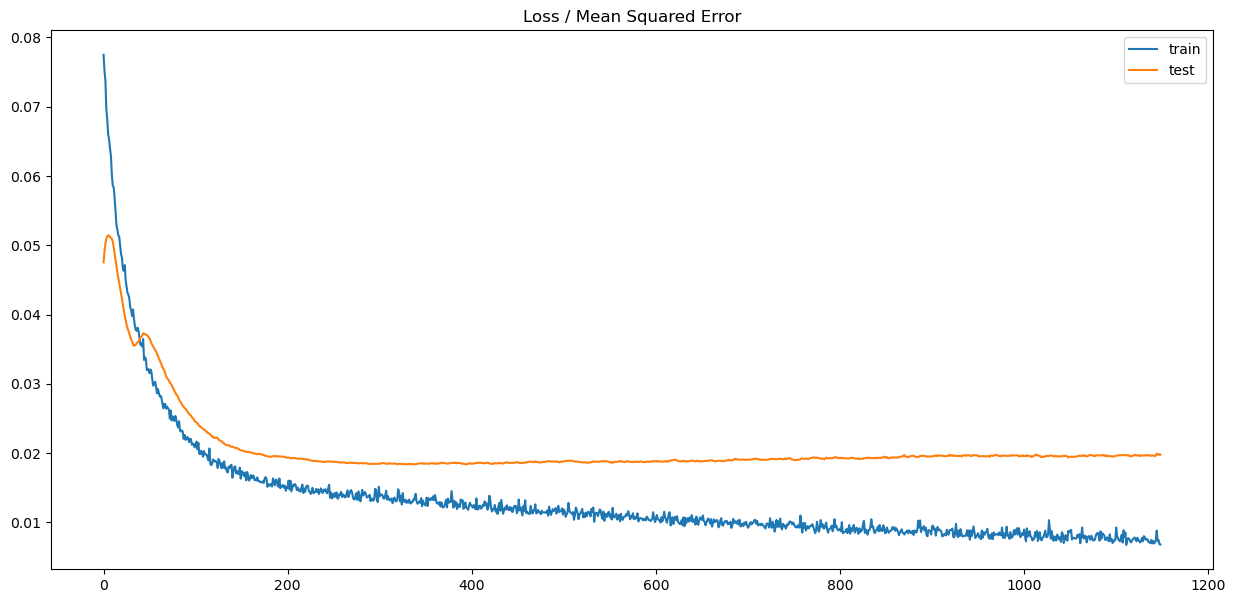

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model5.fit(XX_train, y_train,
                         validation_data=(XX_test, y_test), epochs=3000, callbacks=[early_stopping], verbose = 0)#
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model5.evaluate(XX_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0177 


0.01978481560945511

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model5.predict(XX))

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     3387.
Date:                Sun, 25 Aug 2024   Prob (F-statistic):          3.36e-270
Time:                        21:37:19   Log-Likelihood:                -5685.1
No. Observations:                 701   AIC:                         1.137e+04
Df Residuals:                     699   BIC:                         1.138e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.2884     84.735     -0.169      0.8

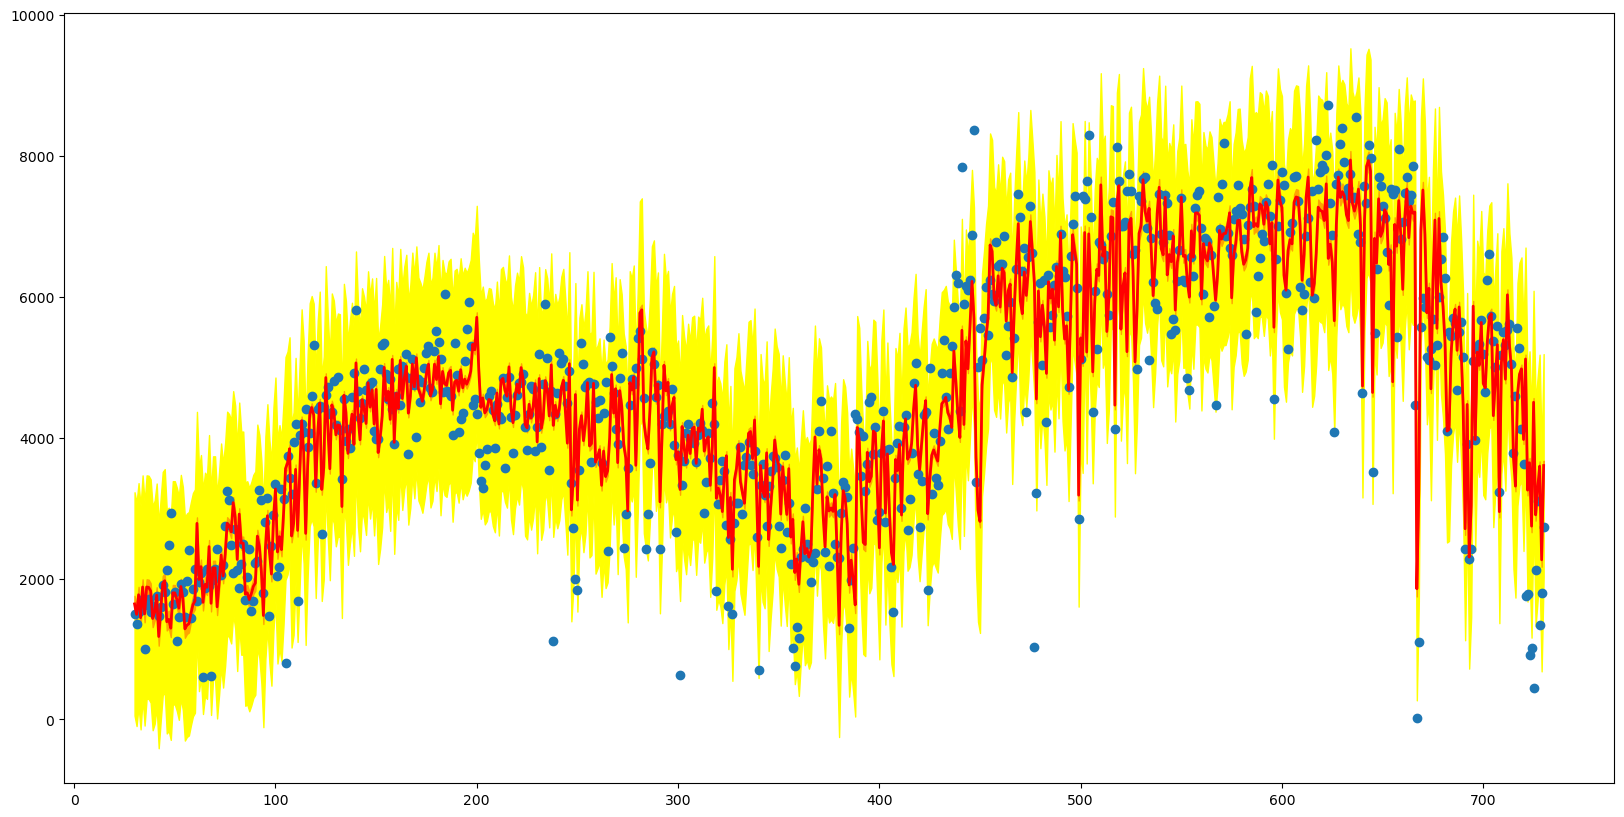

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  651305.400933778


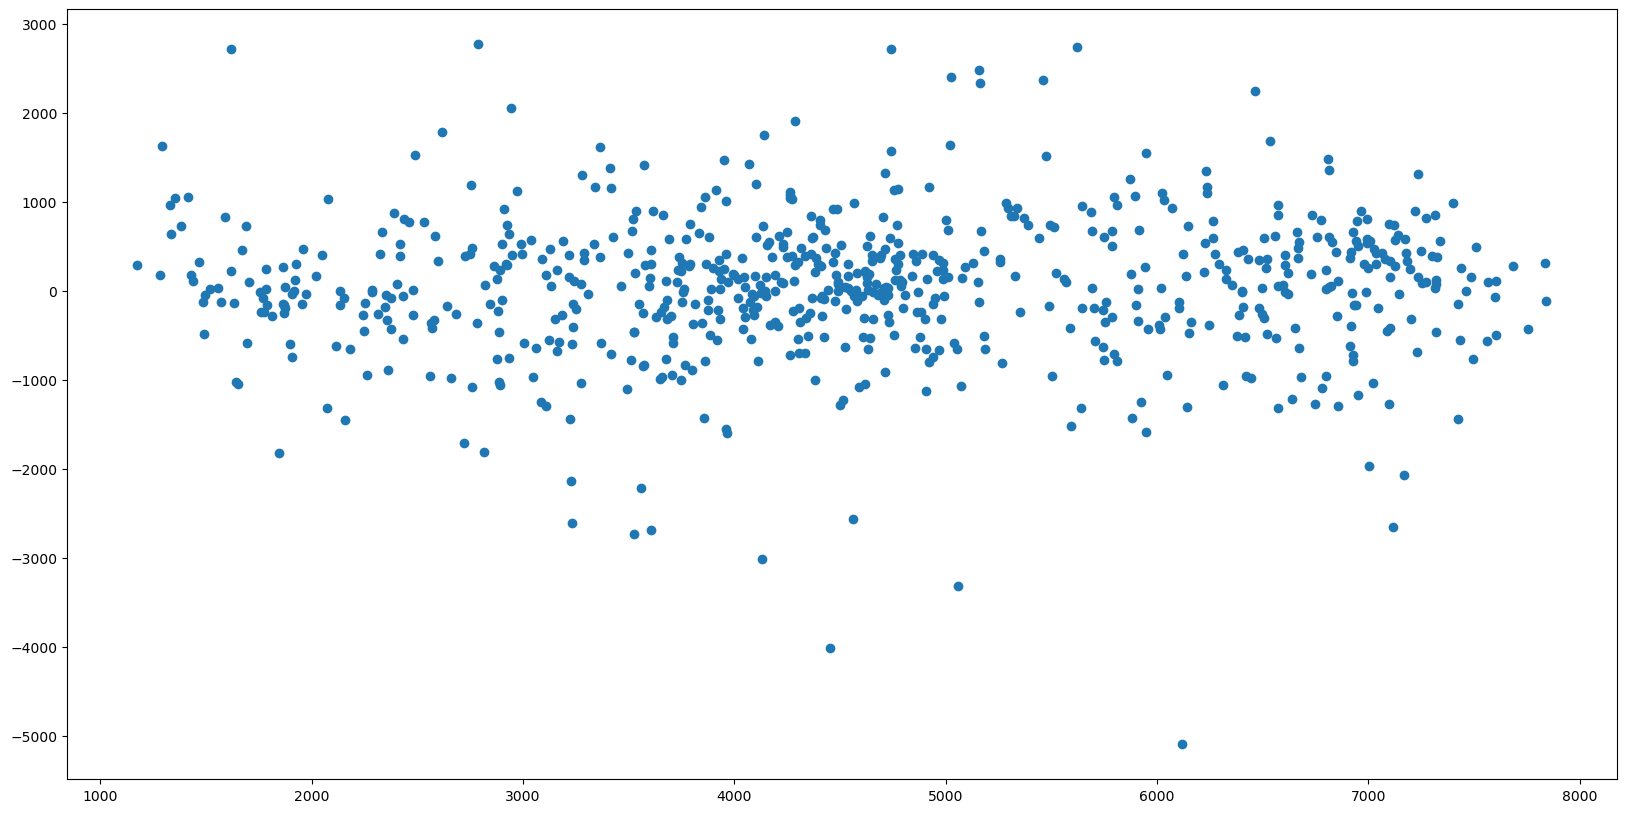

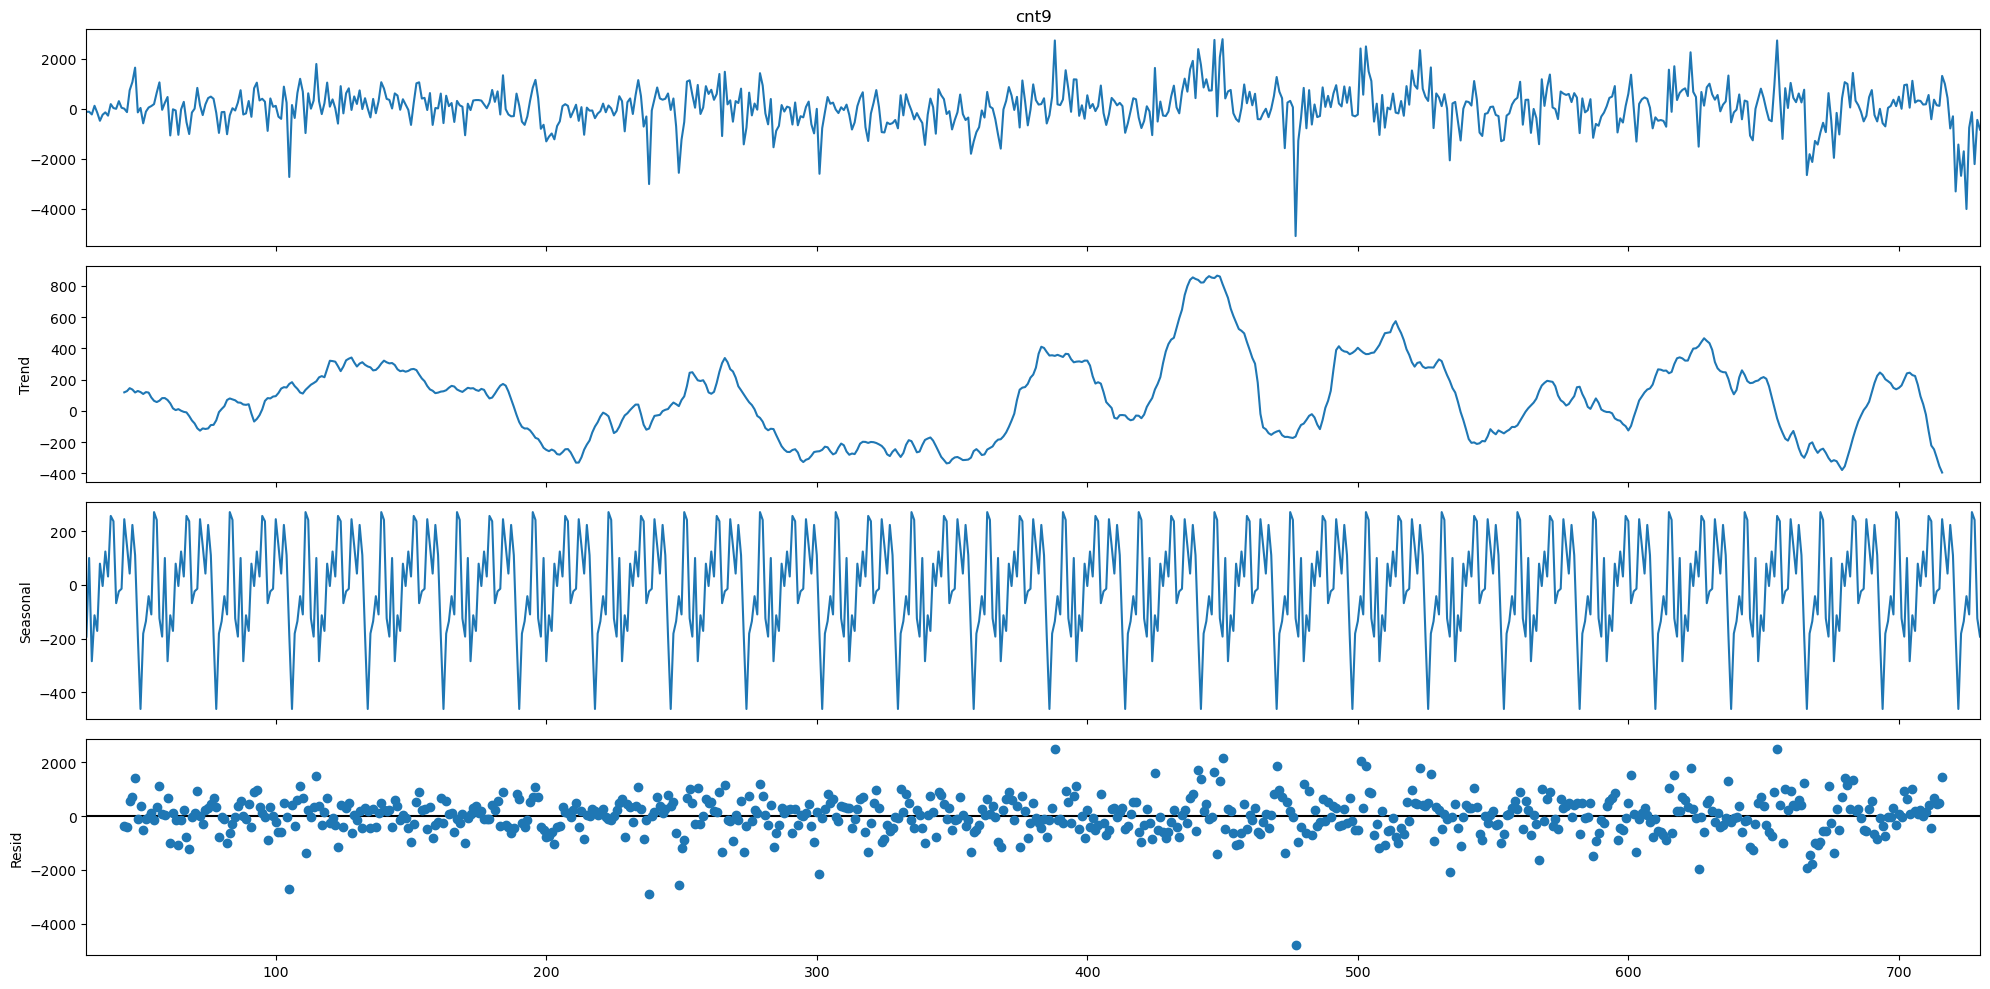

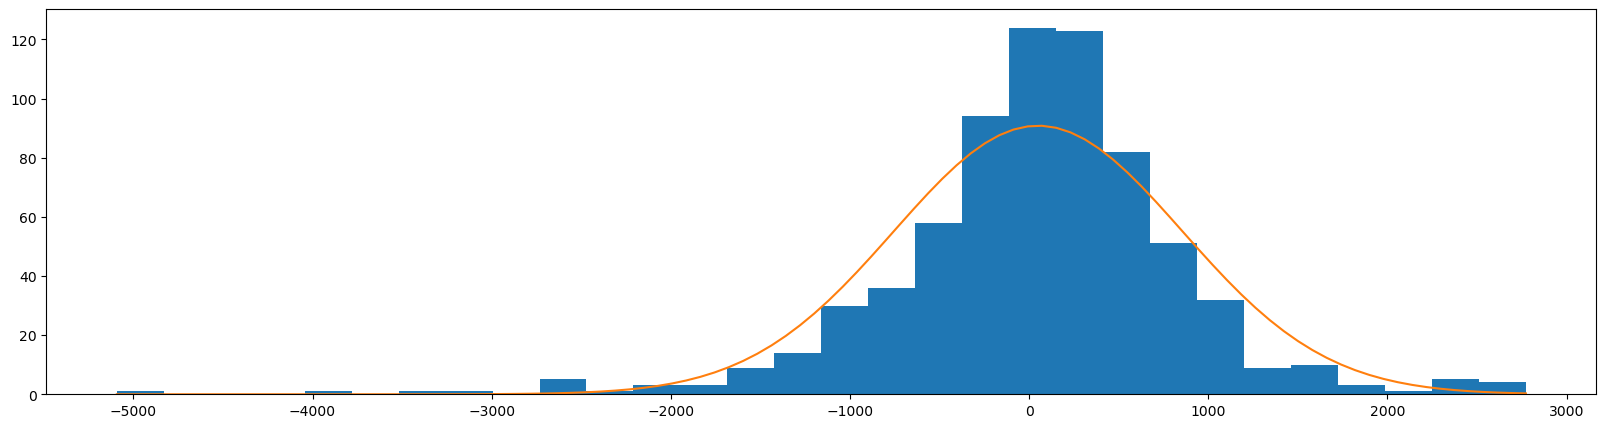

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  5.846622279424883e-16
Критерий Пирсона (проверка на нормальность, p>0.05): 1.7909395362450058e-29
Критерий Харке-Бера (проверка на нормальность, p>0.05): 3.769778391871623e-153
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  1.4814762626505192e-24
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  4.554776570031984e-11
Критерий Стьюдента (проверка на несмещенность, p>0.05):  0.09975460361562742


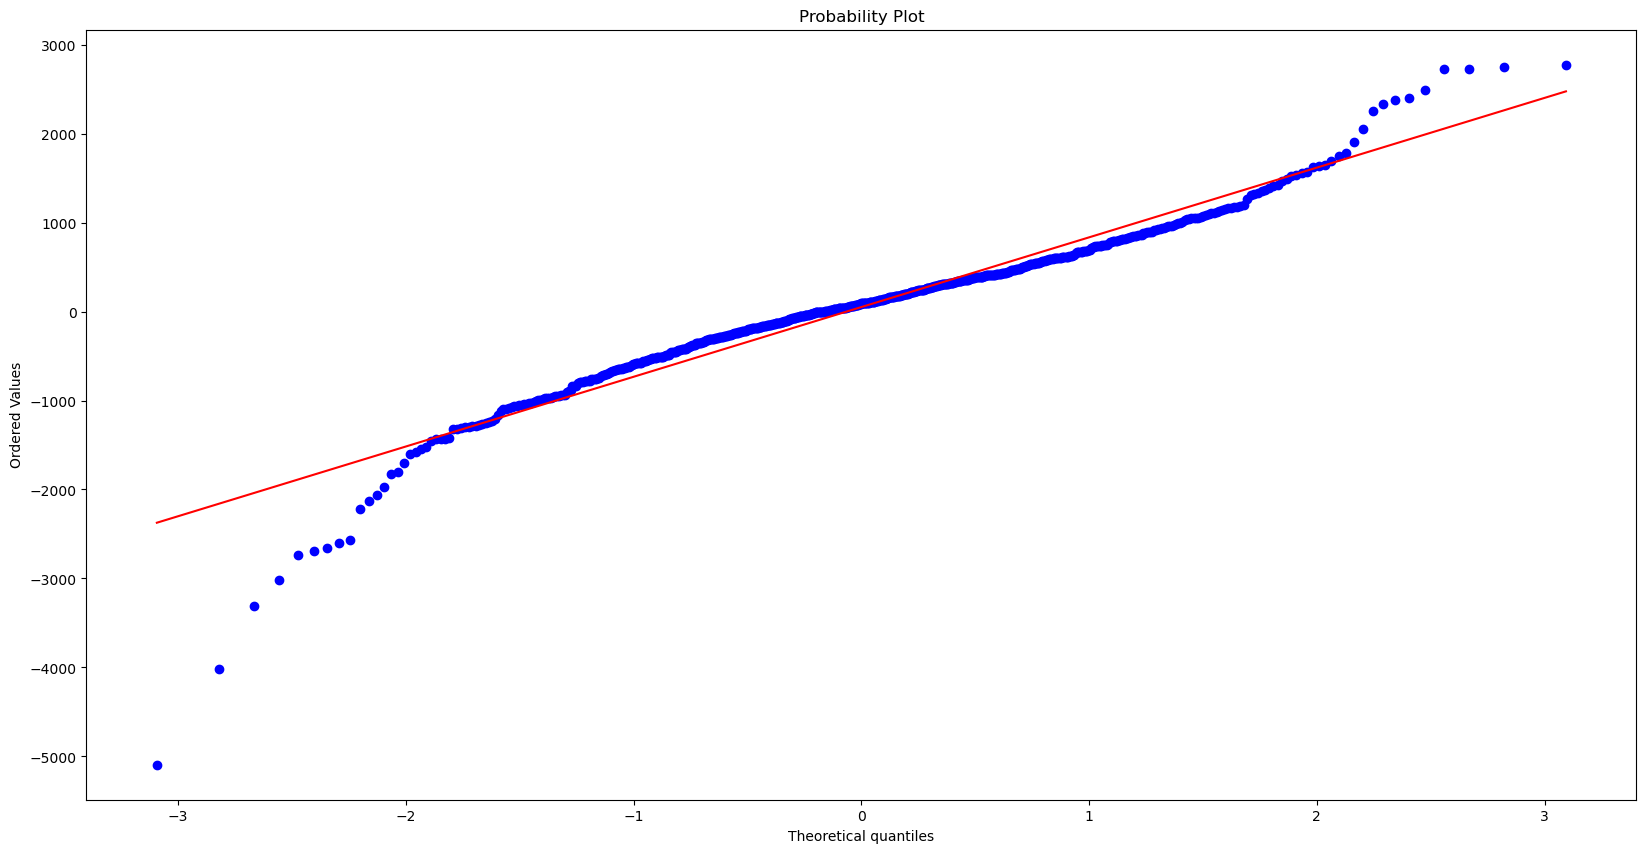

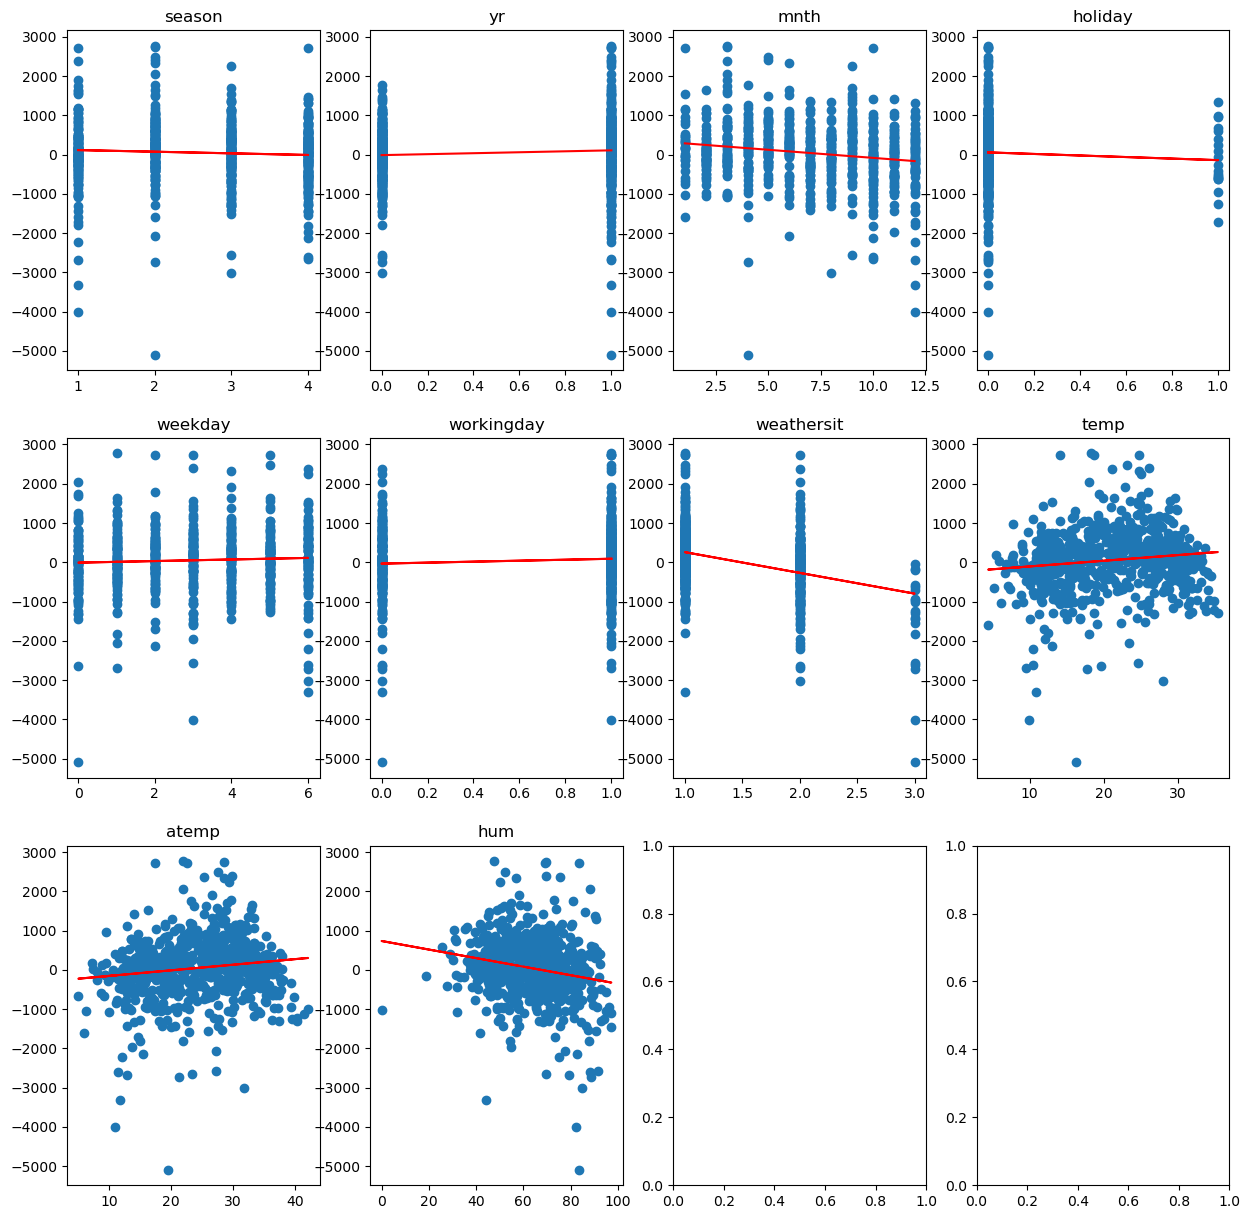

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

## Попробуем отдельные X

In [ ]:
inp = Input(shape=(dfX_train.shape[1], dfX_train.shape[2]))
xmx = []
for el in range(1,5):
    x = Reshape((-1,1))(inp[:,:,el])
    x = Conv1D(filters=15, kernel_size=(6), strides=(1), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPool1D(2)(x)
    x = Conv1D(filters=15, kernel_size=(5), strides=(1), activation='relu')(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)
    xmx.append(x)
ct = Concatenate()(xmx)
rr = Dense(units=15, activation='relu')(ct)
rr = Dense(units=15, activation='relu')(rr)
rr = Dense(units=1, activation='sigmoid')(rr)

model6 = Model(inp, rr)

opt = SGD(learning_rate=0.001)#, momentum=0.9)
model6.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=opt)#tf.optimizers.Adam())

                #metrics=[tf.metrics.MeanSquaredError()]
model6.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 31, 35)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 31)                │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 31)                │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 31)                │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_3 (GetItem)          │ (None, 31)                │               0 │ input_layer_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_1 (Reshape)           │ (None, 31, 1)             │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_2 (Reshape)           │ (None, 31, 1)             │               0 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_3 (Reshape)           │ (None, 31, 1)             │               0 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_4 (Reshape)           │ (None, 31, 1)             │               0 │ get_item_3[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 26, 15)            │             105 │ reshape_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_5 (Conv1D)             │ (None, 26, 15)            │             105 │ reshape_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_7 (Conv1D)             │ (None, 26, 15)            │             105 │ reshape_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_9 (Conv1D)             │ (None, 26, 15)            │             105 │ reshape_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 26, 15)            │              60 │ conv1d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 26, 15)            │              60 │ conv1d_5[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 26, 15)            │              60 │ conv1d_7[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 13,831 (54.03 KB)

 Trainable params: 13,591 (53.09 KB)

 Non-trainable params: 240 (960.00 B)

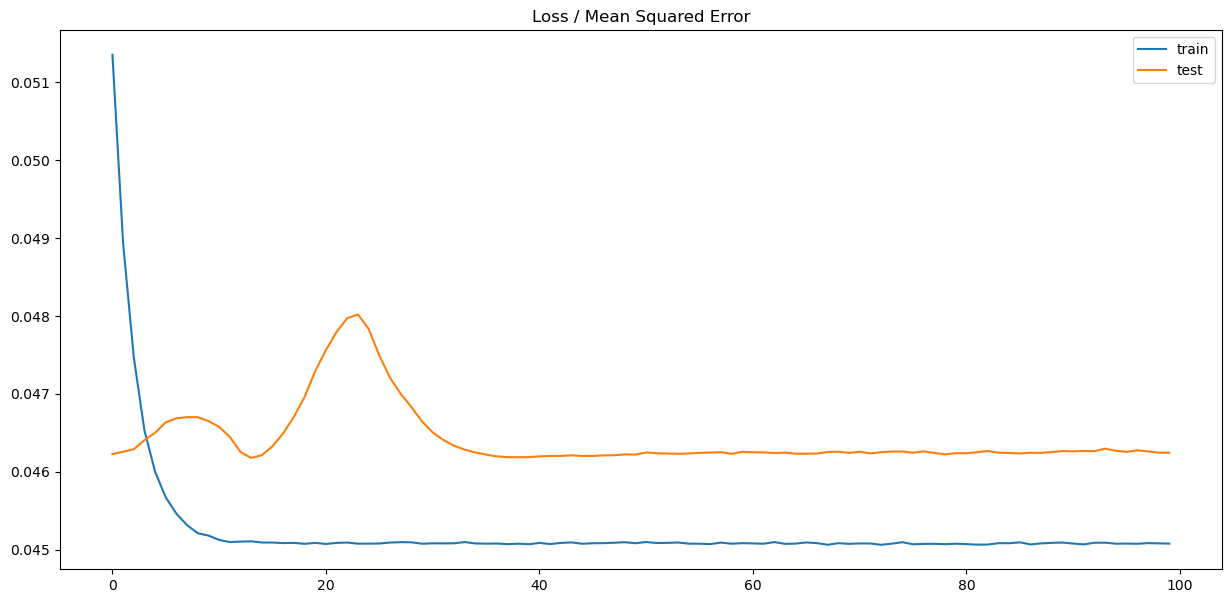

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model6.fit(dfX_train, y_train,
                         validation_data=(dfX_test, y_test), epochs=100, callbacks=[early_stopping], verbose = 0)#
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model6.evaluate(dfX_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0483 


0.04624398052692413

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model6.predict(dfX))

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                     4414.
Date:                Sun, 25 Aug 2024   Prob (F-statistic):          1.75e-304
Time:                        21:37:53   Log-Likelihood:                -6268.2
No. Observations:                 701   AIC:                         1.254e+04
Df Residuals:                     700   BIC:                         1.254e+04
Df Model:                           0                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0002   3.22e-06     66.435      0.0

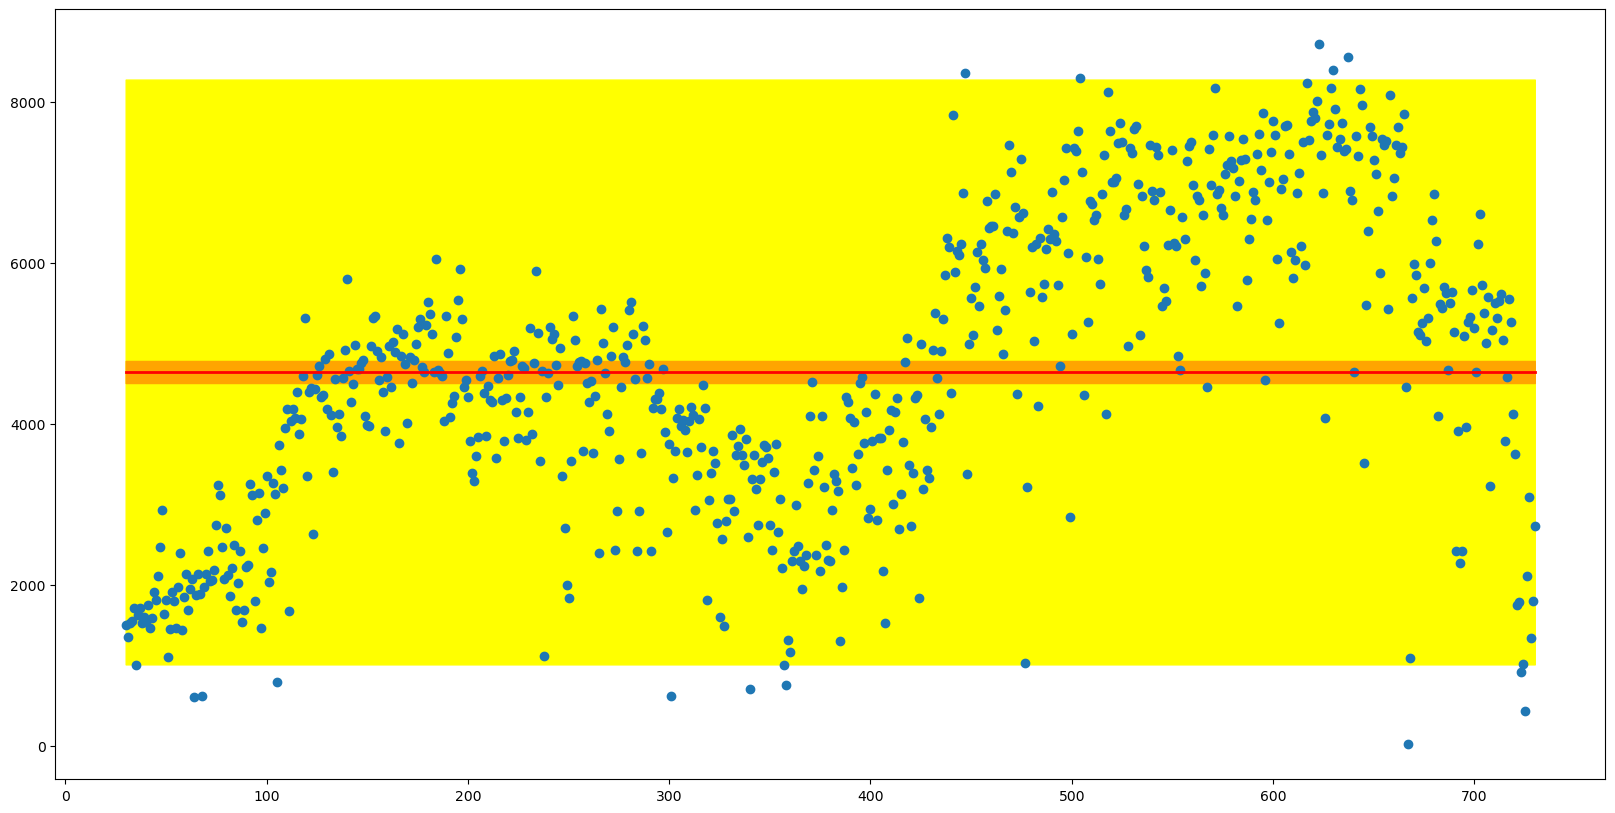

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

# Комбинируем LSTM, GRNN и MLP

In [ ]:
il31 = Input(shape=(len(X_train.columns),), name='input1')
rbf3 = RBFLayer(50, 0.5, initializer = InitCentersBGM(50, X_train))(il31)
d13 = Dense(15, activation='sigmoid')(rbf3)
d23 = Dense(15, activation='sigmoid')(il31)

il32 = Input(shape=(SHAG,), name = 'input2')
rsh3 = Reshape((-1, SHAG))(il32)
lstm31 = LSTM(SYMBOLS, return_sequences=True)(rsh3)
lstm32 = LSTM(SYMBOLS, return_sequences=True)(lstm31)
flt3 = Flatten()(lstm32)
d33 = Dense(units=15, activation='relu')(flt3)

cn3 = Concatenate()([d13, d23, d33])
d43 = Dense(15, activation='sigmoid')(cn3)
d53 = Dense(1, activation='sigmoid')(d43)
model7 = Model(inputs=[il31, il32], outputs=d53)

model7.compile(loss=tf.losses.MeanSquaredError(),
                optimizer=tf.optimizers.Adam())


model7.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input2 (InputLayer)           │ (None, 30)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_5 (Reshape)           │ (None, 1, 30)             │               0 │ input2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 1, 100)            │          52,400 │ reshape_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input1 (InputLayer)           │ (None, 35)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 1, 100)            │          80,400 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rbf_layer_2 (RBFLayer)        │ (None, 50)                │           1,750 │ input1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_6 (Flatten)           │ (None, 100)               │               0 │ lstm_3[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_19 (Dense)              │ (None, 15)                │             765 │ rbf_layer_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_20 (Dense)              │ (None, 15)                │             540 │ input1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_21 (Dense)              │ (None, 15)                │           1,515 │ flatten_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 45)                │               0 │ dense_19[0][0],            │
│                               │                           │                 │ dense_20[0][0],            │
│                               │                           │                 │ dense_21[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_22 (Dense)              │ (None, 15)                │             690 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_23 (Dense)              │ (None, 1)                 │              16 │ dense_22[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 138,076 (539.36 KB)

 Trainable params: 138,076 (539.36 KB)

 Non-trainable params: 0 (0.00 B)

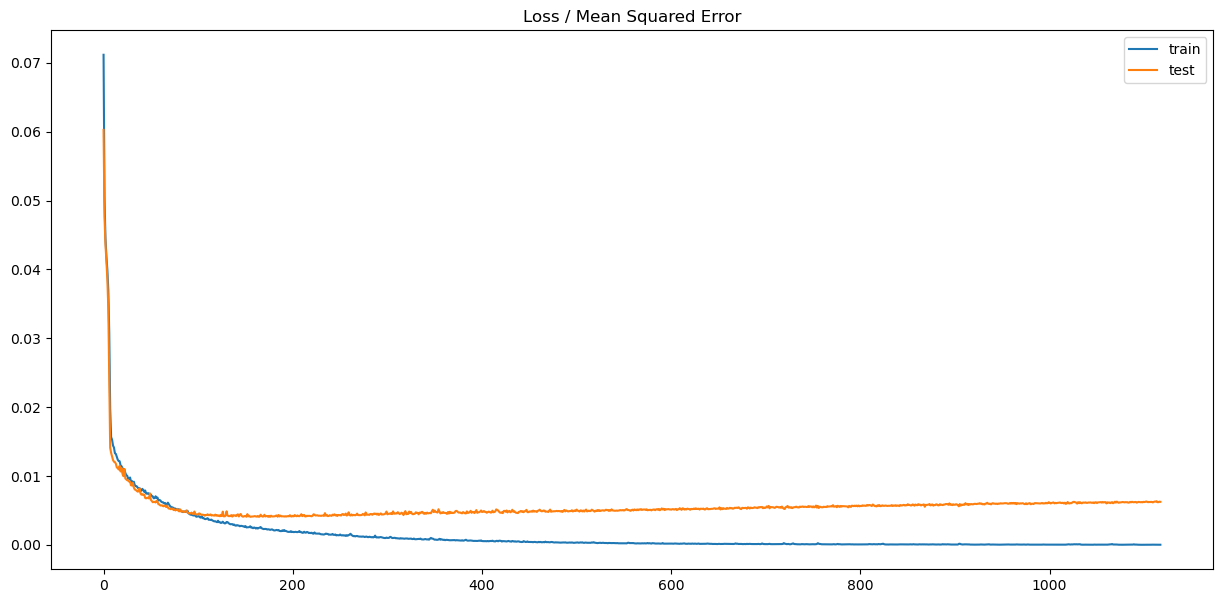

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, mode='min', start_from_epoch=1000)

history = model7.fit([X_train, XX_train], y_train,
                         validation_data=([np.array(X_test), XX_test], y_test), epochs=3000, callbacks=[early_stopping], verbose = 0)#
plt.figure(figsize=(15,7))
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# evaluate the keras model
model7.evaluate([X_test, XX_test], y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0060 


0.006252872291952372

In [ ]:
dff['cnt1']=y_scaler.inverse_transform(model7.predict([df2, XX]))

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step 


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                 2.749e+04
Date:                Sun, 25 Aug 2024   Prob (F-statistic):               0.00
Time:                        21:41:11   Log-Likelihood:                -5013.1
No. Observations:                 701   AIC:                         1.003e+04
Df Residuals:                     699   BIC:                         1.004e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     73.2864     32.417      2.261      0.0

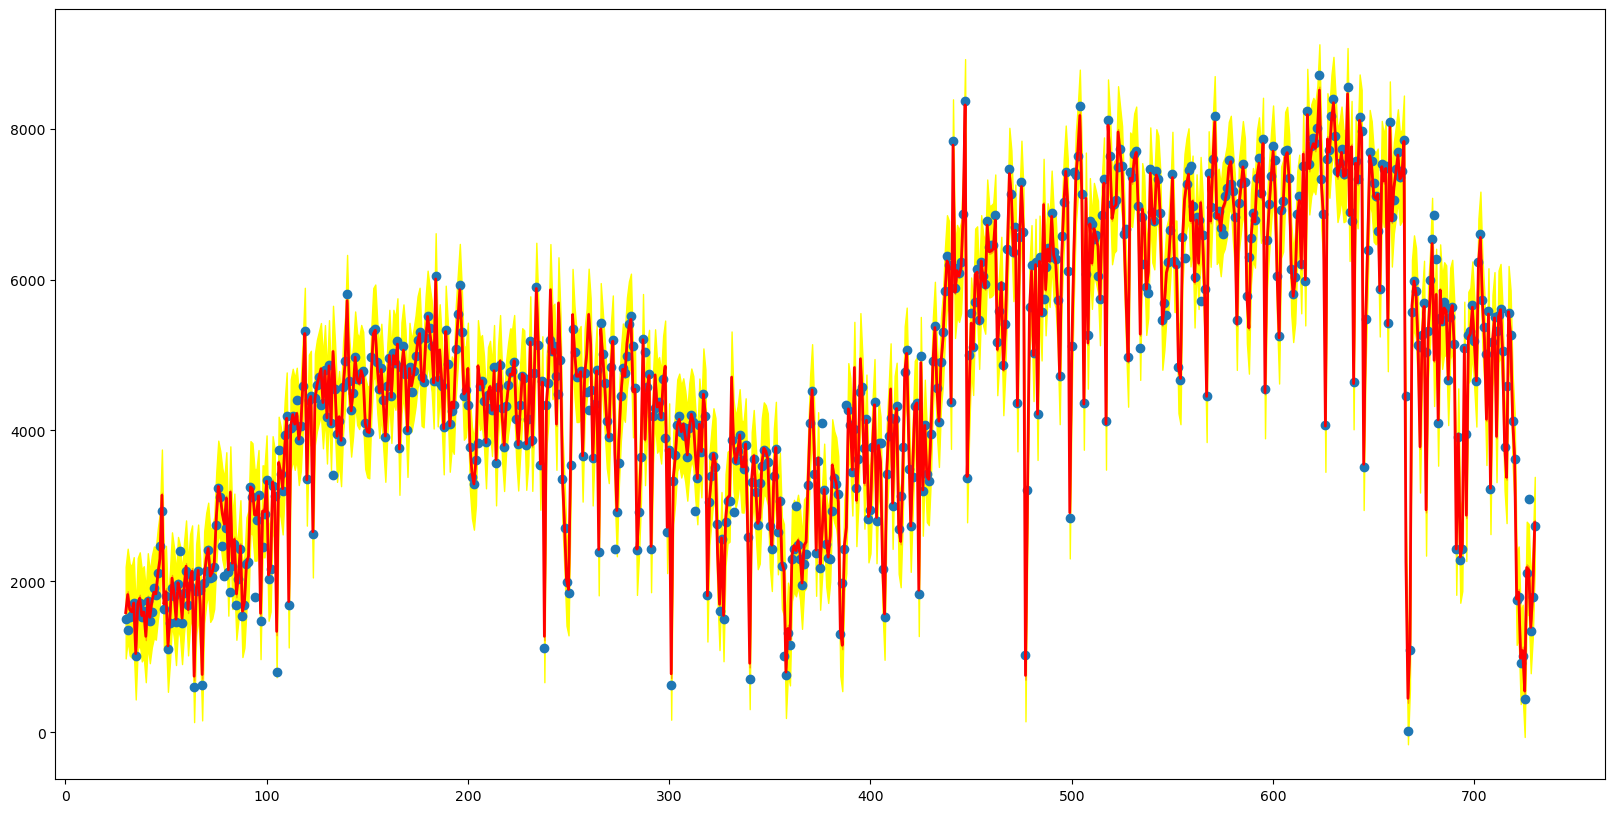

In [ ]:
# Визуализируем полученные результаты
model = smf.ols('cnt ~ cnt1',data=dff).fit(cov_type='HC1')
print(model.summary())
res=model.get_prediction(exog=dff)

res_mn= (res.predicted_mean)

sf2=res.summary_frame(alpha=0.05)
res_lo=sf2['obs_ci_lower']
res_up=sf2['obs_ci_upper']
res_lom=sf2['mean_ci_lower']
res_upm=sf2['mean_ci_upper']


plt.fill_between(dff.indx,np.array(res_lo),np.array(res_up),color='yellow')
plt.fill_between(dff.indx,np.array(res_lom),np.array(res_upm),color='orange')
plt.plot(dff.indx,res_mn,color='red',linewidth=2)
plt.scatter(dff.indx,dff.cnt)
#plt.plot(df.indx,df.cnt1)
plt.show()

MSE:  96053.69209010234


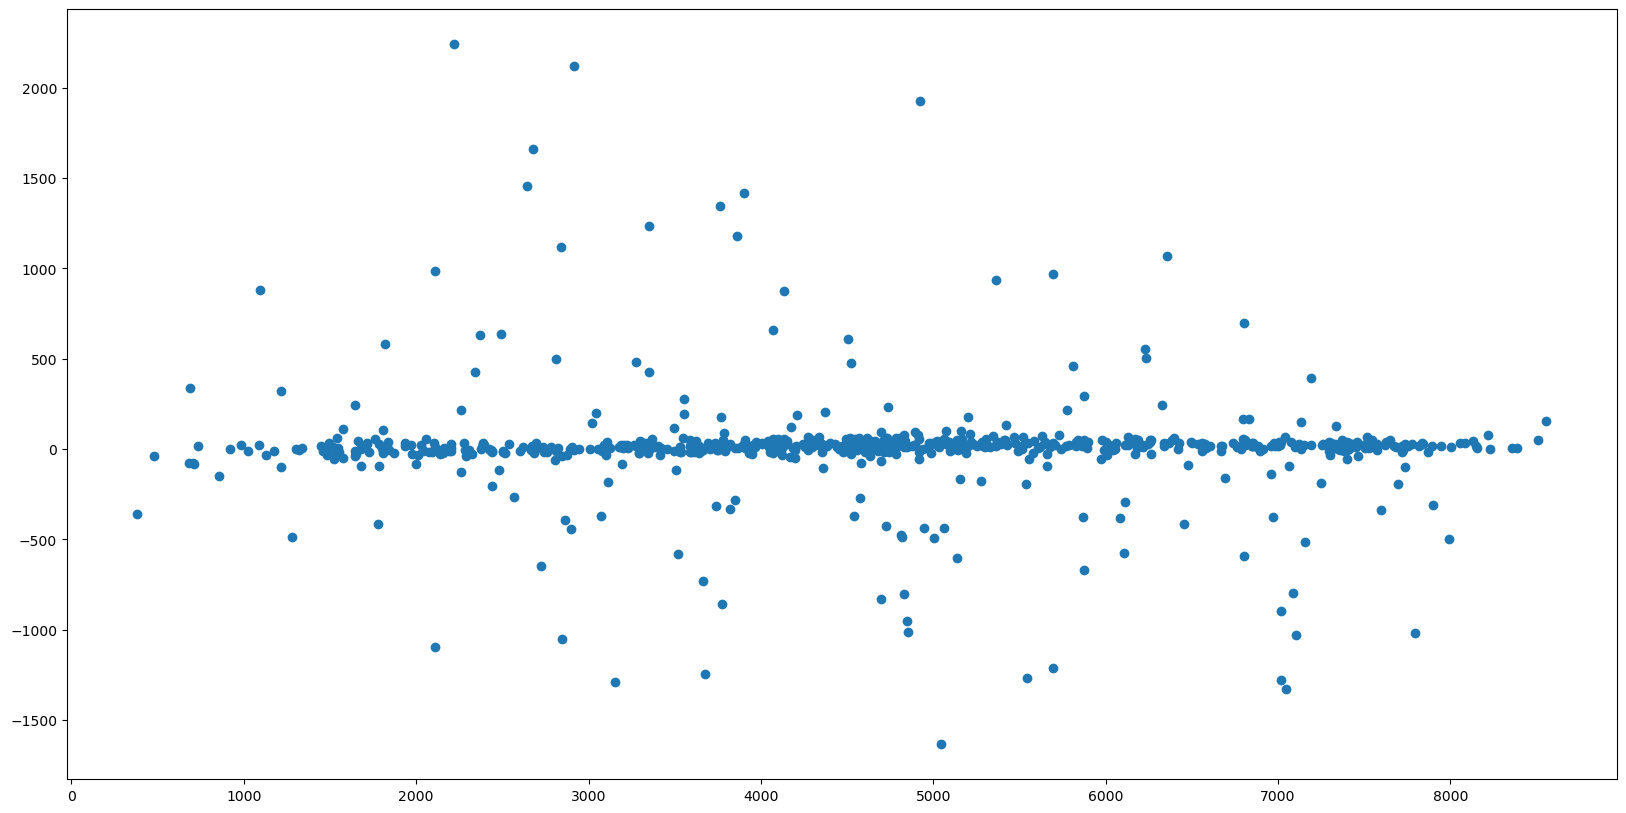

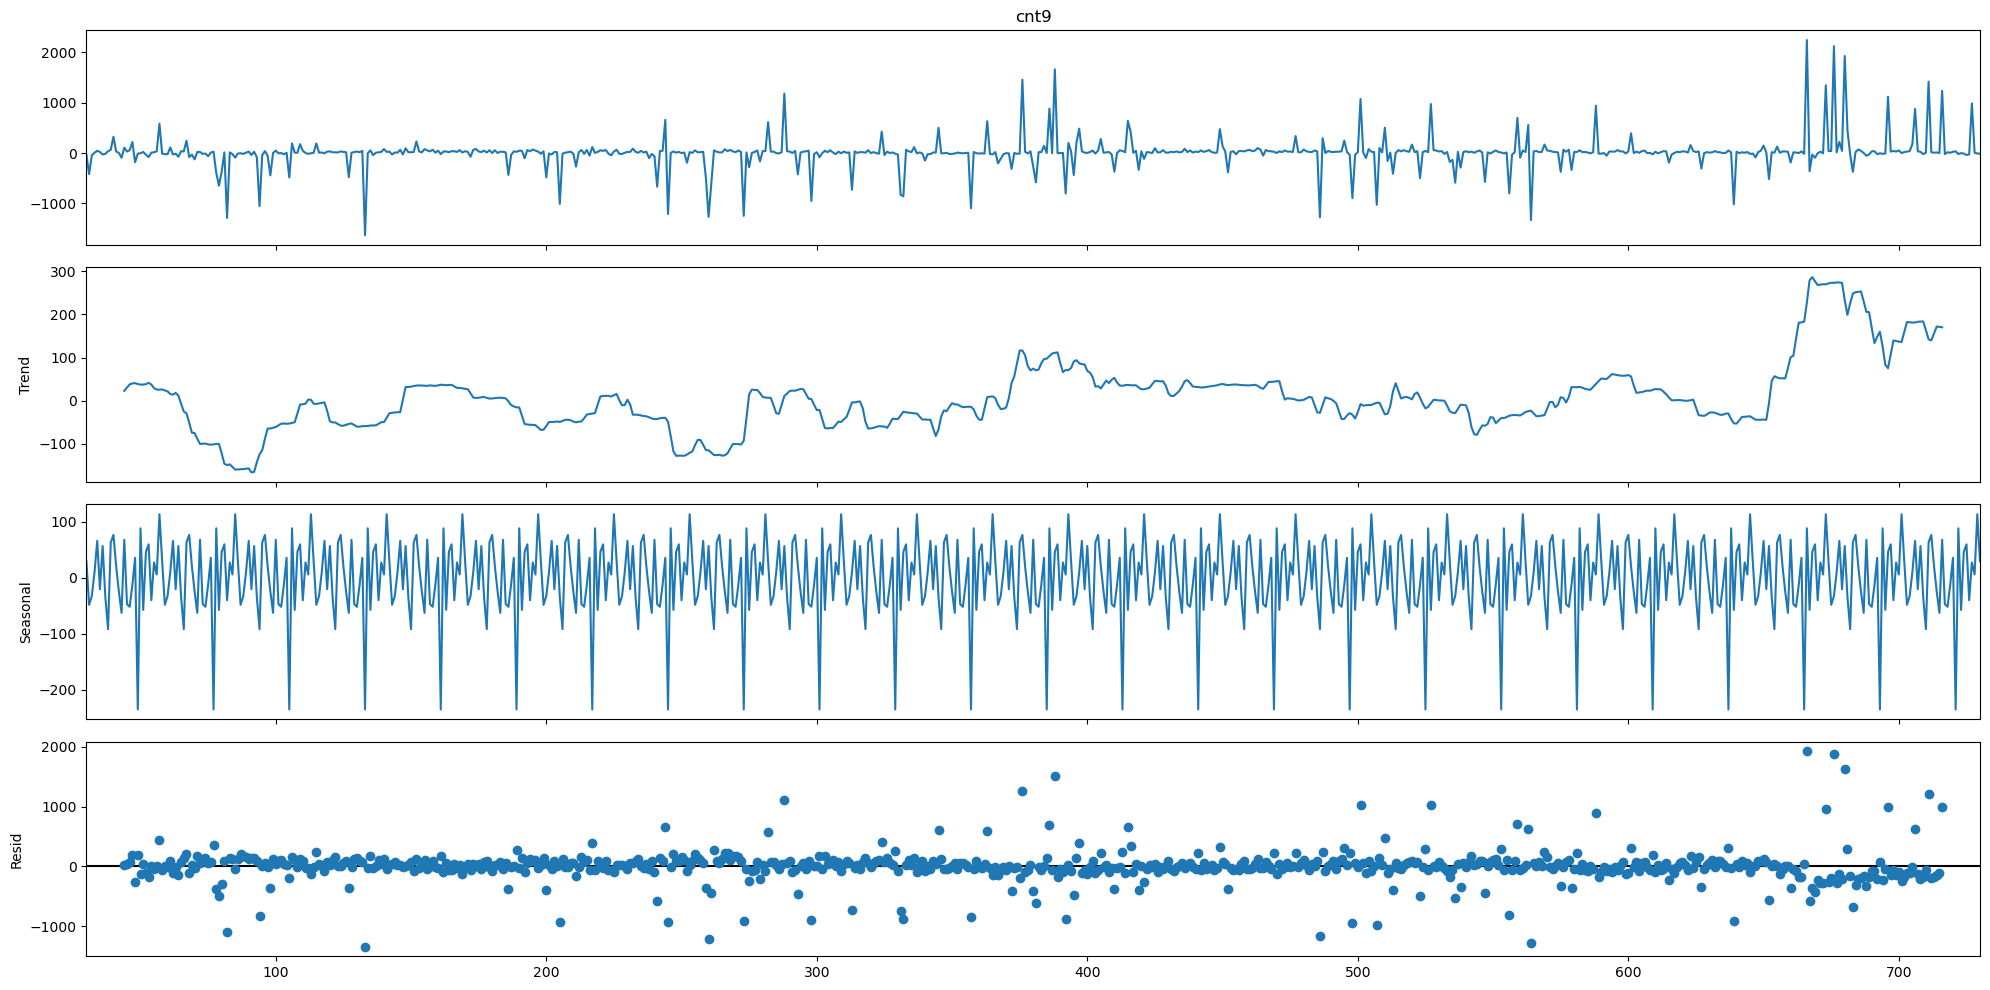

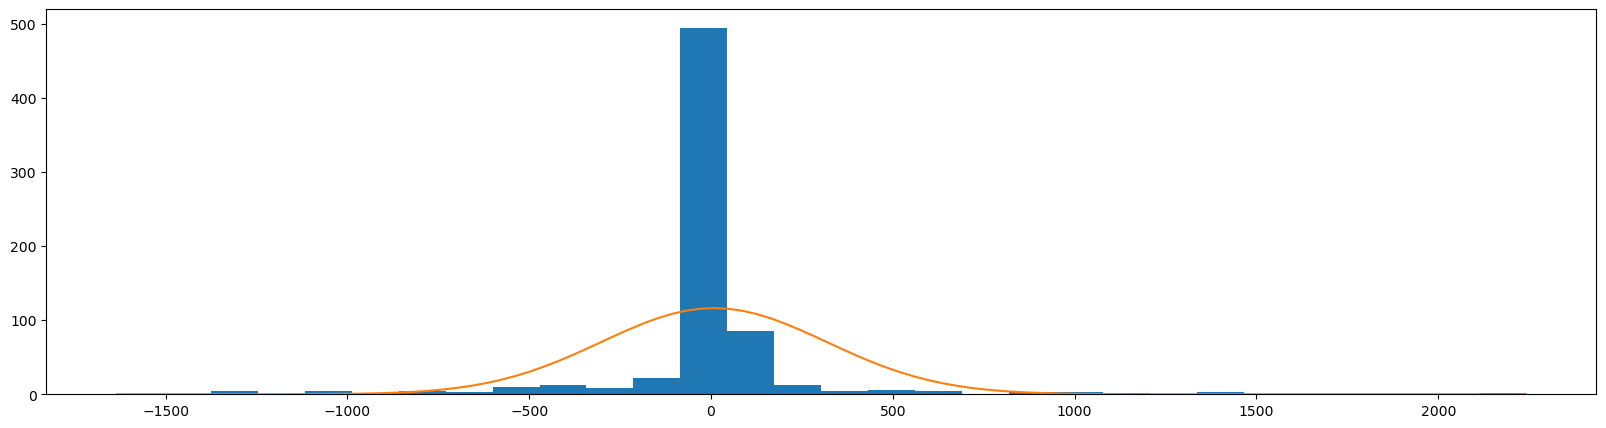

Критерий Шапиро-Уилка (проверка на нормальность, p>0.05):  1.6902581553011543e-38
Критерий Пирсона (проверка на нормальность, p>0.05): 1.2094185450212211e-58
Критерий Харке-Бера (проверка на нормальность, p>0.05): 0.0
Критерий Дики-Фуллера (проверка на стационарность, p<0.05):  0.0
Критерий Голдфелда-Квандта (проверка на гетероскедастичность,тестируем наличие линейного тренда), p<0.05):  1.2967109269821259e-06
Критерий Стьюдента (проверка на несмещенность, p>0.05):  0.4840602356759407


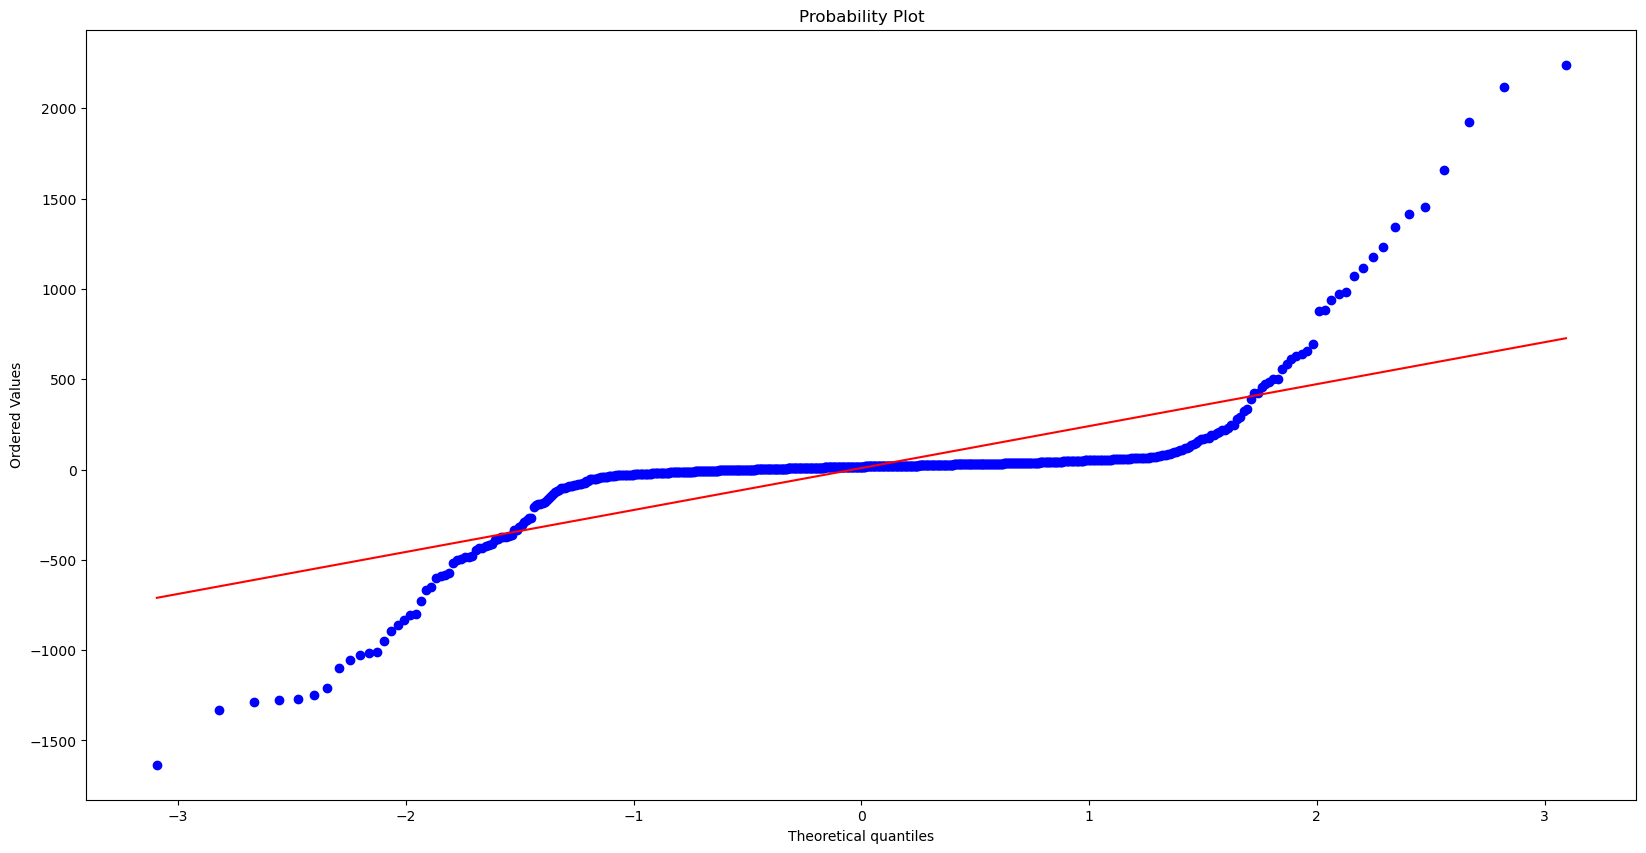

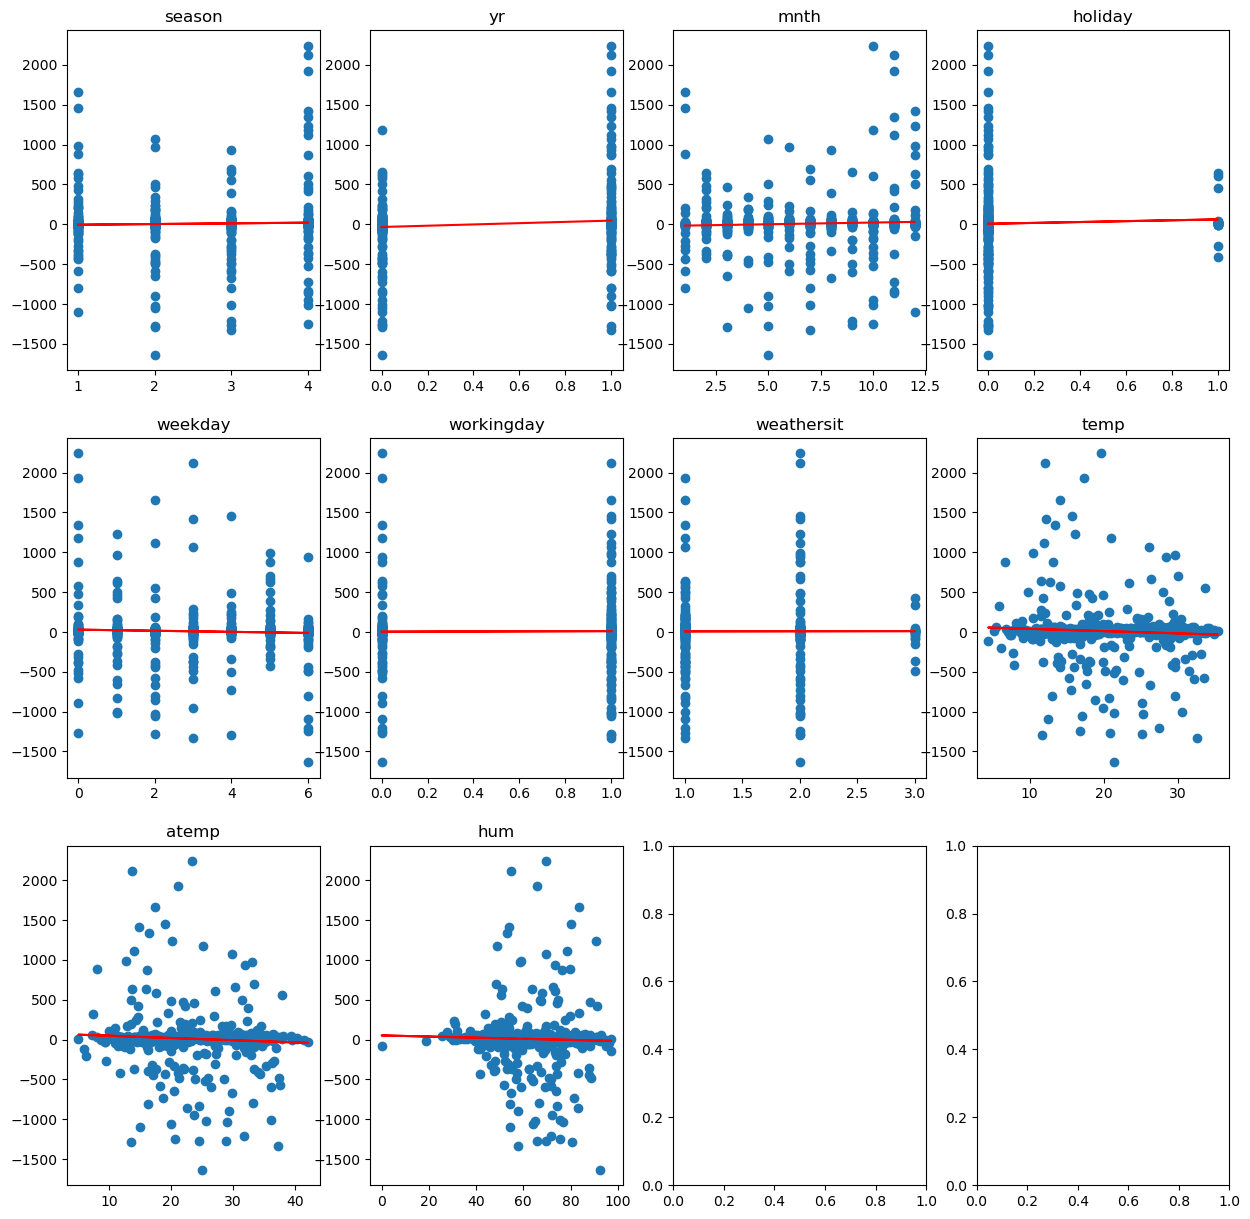

In [ ]:
# Оцениваем качество модели
print('MSE: ',mse(dff.cnt,dff.cnt1))

# Смотрим остатки
dff['cnt9']=dff.cnt-dff.cnt1
plt.scatter(dff.cnt1,dff.cnt9)
plt.show()

# Тестируем остатки
res_decompose(dff.cnt9,per=28)
res_hist(dff.cnt9)
resides_test(dff.cnt9)

# Смотрим, остались ли еще зависимости с внешними факторами
fig, axes = plt.subplots(3, 4,figsize=(15,15))

for idx,parametr in enumerate(df.columns[:-4]):
    model1=LR().fit(dff[[parametr]],dff['cnt9'])
    axes[idx //4, idx%4].scatter(dff[parametr],dff['cnt9'])
    axes[idx //4, idx%4].plot(dff[parametr],model1.predict(dff[[parametr]]),color='red')

    axes[idx //4, idx%4].set_title(parametr)

https://towardsdatascience.com/implementing-alexnet-cnn-architecture-using-tensorflow-2-0-and-keras-2113e090ad98